In [29]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import RobustScaler
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
import xgboost 
from sklearn.manifold import TSNE
from sklearn.metrics import (
    mean_absolute_error,mean_squared_error,r2_score,root_mean_squared_error
)

plt.style.use('default')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)


In [30]:

df = pd.read_csv('Copia de data_merged.csv')



In [31]:

def aux(temp):
    if temp<=80:
        return 'lento'
    elif temp <=120:
        return 'moderado'
    return 'rapido'

df['duration_ms']= df['duration_ms']/60000
df['duration_ms_ar'] = df['duration_ms_ar']/60000
df['duration_ms_yr'] = df['duration_ms_yr']/60000

df['energy_ratio_yr'] = df['energy_yr']*df['acousticness_yr']
df['electro_focus_yr'] = (1-df['acousticness_yr'])*df['energy_yr']*df['instrumentalness_yr']
df['vocal_energy_yr'] = (1-df['instrumentalness_yr'])*df['energy_yr']

df['energy_ratio_'] = df['energy']*df['acousticness']
df['electro_focus'] = (1-df['acousticness'])*df['energy']*df['instrumentalness']
df['vocal_energy'] = (1-df['instrumentalness'])*df['energy']

df['energy_ratio_ar'] = df['energy_ar']*df['acousticness_ar']
df['electro_focus_ar'] = (1-df['acousticness_ar'])*df['energy_ar']*df['instrumentalness_ar']
df['vocal_energy_ar'] = (1-df['instrumentalness_ar'])*df['energy_ar']


df['temp_range'] = df['tempo_yr'].apply(aux)
df = pd.get_dummies(df,columns=['temp_range'],prefix='temp')
df[['temp_moderado','temp_rapido']] = df[['temp_moderado','temp_rapido']].astype(int)

In [32]:
df

,acousticness,danceability,duration_ms,energy,explicit,instrumentalness,liveness,loudness,popularity,speechiness,...,electro_focus_yr,vocal_energy_yr,energy_ratio_,electro_focus,vocal_energy,energy_ratio_ar,electro_focus_ar,vocal_energy_ar,temp_moderado,temp_rapido
0,0.013100,0.2560,3.039117,0.895,0,0.000106,0.0821,-4.860,29,0.0707,...,0.037649,0.495522,0.011725,0.000094,0.894905,0.105519,1.463051e-02,0.709725,0,1
1,0.980000,0.2770,3.449533,0.145,0,0.879000,0.1110,-19.898,0,0.0845,...,0.009108,0.183282,0.142100,0.002549,0.017545,0.208915,4.504740e-03,0.097838,1,0
2,0.795000,0.6850,5.244450,0.483,0,0.878000,0.1130,-10.202,1,0.0337,...,0.010180,0.186780,0.383985,0.086935,0.058926,0.491828,6.804020e-02,0.059278,1,0
3,0.656000,0.7880,2.995783,0.808,0,0.000000,0.1540,-6.590,0,0.0395,...,0.010180,0.186780,0.530048,0.000000,0.808000,0.537642,2.723306e-07,0.744999,1,0
4,0.302000,0.0753,8.309333,0.150,0,0.884000,0.1210,-16.705,0,0.0371,...,0.007777,0.179243,0.045300,0.092555,0.017400,0.253033,3.753181e-02,0.103445,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
172225,0.000067,0.5670,0.616667,0.862,0,0.875000,0.4810,-5.617,0,0.0670,...,0.116161,0.507938,0.000058,0.754199,0.107750,0.000040,5.311705e-01,0.370306,0,1
172226,0.000994,0.3960,8.363733,0.979,0,0.609000,0.1360,-9.138,0,0.0878,...,0.133639,0.491948,0.000973,0.595618,0.382789,0.016665,1.873520e-01,0.759704,0,1
172227,0.864000,0.6380,2.692667,0.156,0,0.000000,0.1830,-17.372,20,0.0741,...,0.013051,0.250225,0.134784,0.000000,0.156000,0.131158,2.533831e-04,0.142178,1,0
172228,0.029900,0.5330,5.713783,0.547,0,0.011300,0.0723,-9.290,35,0.0326,...,0.031967,0.443442,0.016355,0.005996,0.540819,0.098186,1.820001e-02,0.678454,1,0


In [33]:

df_processed = df.copy()

initial_rows = len(df_processed)
df_processed = df_processed.dropna()

def categorize_popularity(popularity):
    if popularity<=20:
        return 0 # baja
    elif popularity <=45:
        return 1 # media
    return 2 # alta
    

df_processed['popularity_multiclass'] = df_processed['popularity'].apply(categorize_popularity)
print("\nVariable multiclase 3 niveles (popularity_multiclass):")
multiclass_counts = df_processed['popularity_multiclass'].value_counts().sort_index()
multiclass_labels = ['Baja', 'Media', 'Alta']
for i, (count, label) in enumerate(zip(multiclass_counts, multiclass_labels)):
    print(f"   {i} ({label}): {count} ({count/len(df_processed)*100:.1f}%)")




Variable multiclase 3 niveles (popularity_multiclass):
   0 (Baja): 73762 (42.8%)
   1 (Media): 62074 (36.0%)
   2 (Alta): 36394 (21.1%)


<Axes: xlabel='popularity_multiclass'>

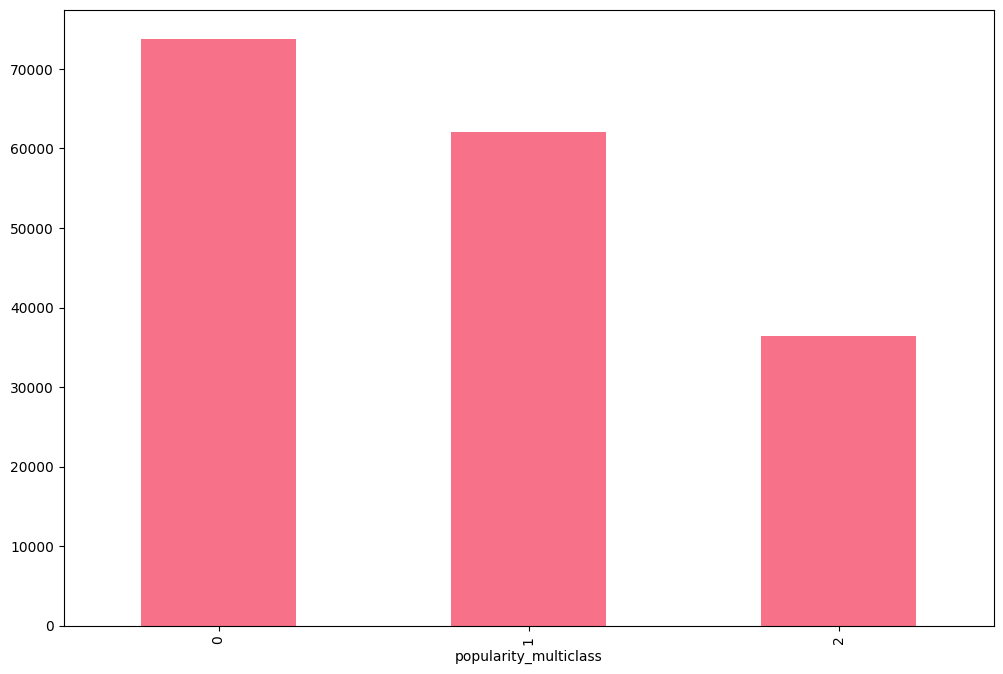

In [34]:
df_processed['popularity_multiclass'].value_counts().plot(kind='bar')

In [35]:


_X = df_processed.copy()

X = _X.drop(columns=['popularity','popularity_multiclass'])
y_multiclass_3 = df_processed['popularity_multiclass'] 



In [36]:
df_processed.groupby('popularity_multiclass')['popularity'].describe()

,count,mean,std,min,25%,50%,75%,max
popularity_multiclass,,,,,,,,
0,73762.0,4.438369,6.348734,0.0,0.0,0.0,8.0,20.0
1,62074.0,32.917051,6.956338,21.0,27.0,33.0,39.0,45.0
2,36394.0,57.551904,8.900427,46.0,50.0,56.0,63.0,100.0


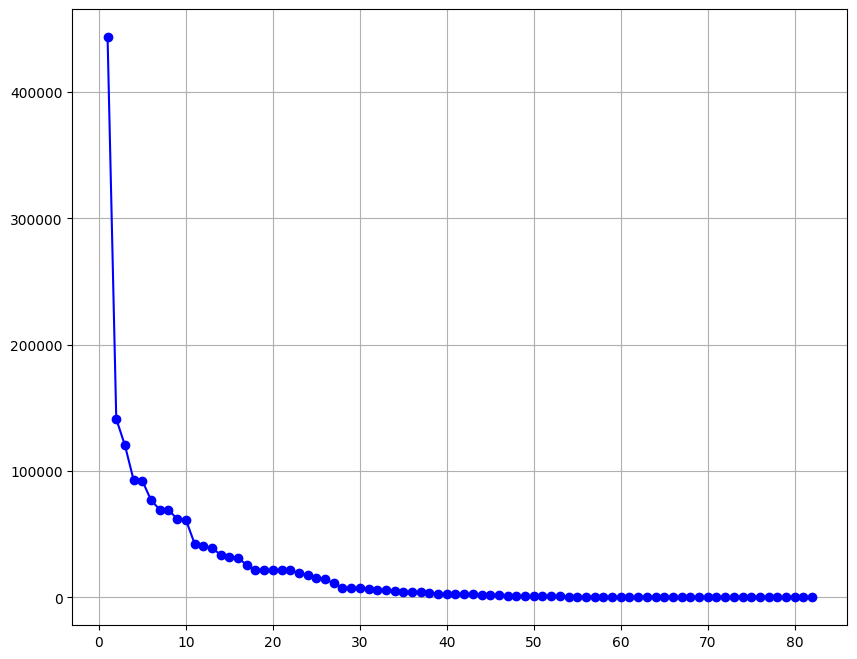

In [37]:

selector = SelectKBest(score_func=f_regression,k='all')
X_new = selector.fit_transform(X,y_multiclass_3)
total_score = selector.scores_
sorted_scoress = np.sort(total_score)[::-1]
plt.figure(figsize=(10,8))
plt.grid(visible=True)
plt.plot(range(1,X.shape[1]+1),sorted_scoress,'bo-')


In [38]:
selector = SelectKBest(score_func=f_regression,k=6)
X_new = selector.fit_transform(X,y_multiclass_3)
select = selector.get_feature_names_out()
select


array(['popularity_ar', 'acousticness_yr', 'energy_yr', 'tempo_yr',
       'popularity_yr', 'vocal_energy_yr'], dtype=object)

In [39]:
_X=X.copy()
y =y_multiclass_3

In [40]:
scaler1 = RobustScaler()

X_train_reduce, X_test_reduce, y_train_reduce, y_test_reduce = train_test_split(
    _X, y, 
    test_size=0.2, 
    stratify=y,
    random_state=42
)


In [41]:
X_train_reduce = scaler1.fit_transform(X_train_reduce)
X_test_scaled = scaler1.transform(X_test_reduce)

Fitting 5 folds for each of 3 candidates, totalling 15 fits

RandomForest
Best params: {'max_depth': 20}
r2: 0.7375273506826796
rmse: 0.3943586984240391
mae 0.1513963885501945
mse: 0.1555187830227022


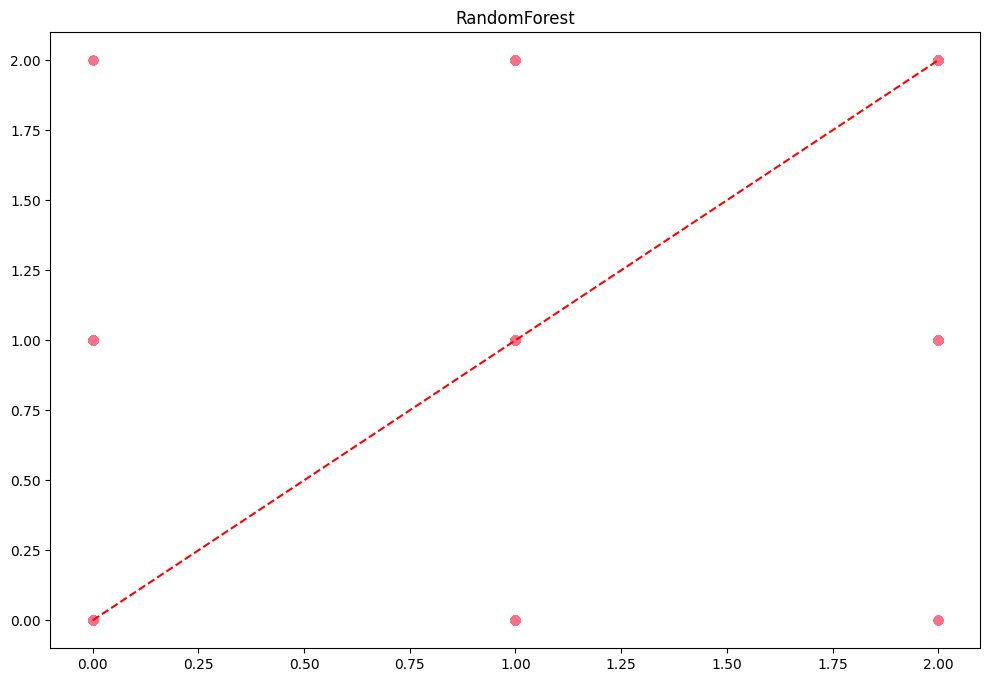

operands could not be broadcast together with shapes (137784,) (34446,) 
Fitting 5 folds for each of 6 candidates, totalling 30 fits

HistoradientBoosting
Best params: {'max_depth': 5, 'max_iter': 300}
r2: 0.7287080344838524
rmse: 0.4009293622083702
mae 0.15656389711432386
mse: 0.16074435348081054


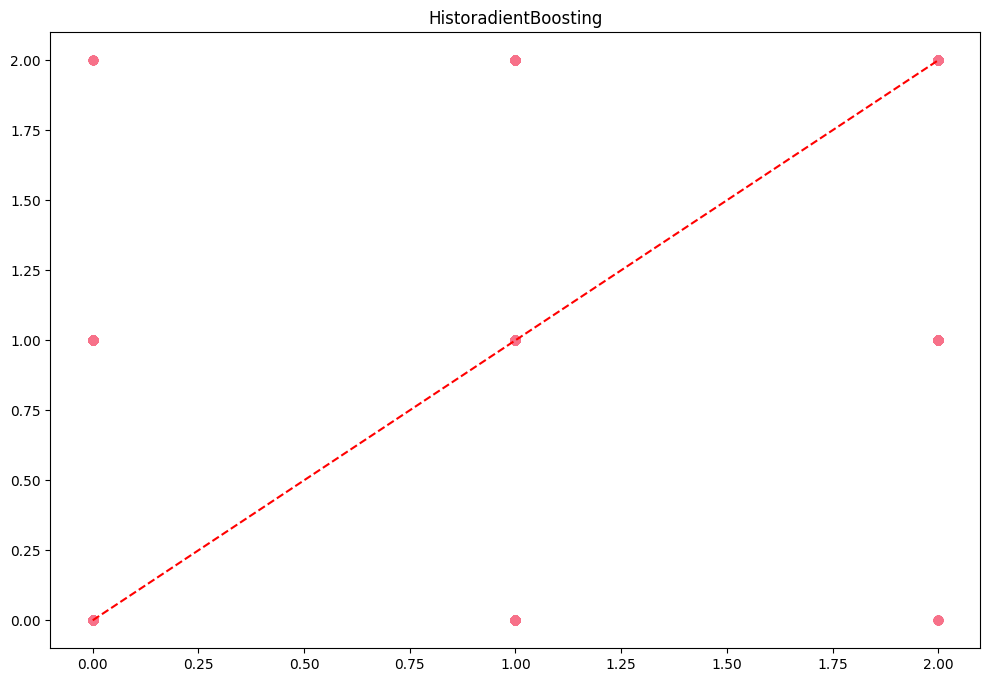

operands could not be broadcast together with shapes (137784,) (34446,) 
Fitting 5 folds for each of 9 candidates, totalling 45 fits

XGBoost
Best params: {'max_depth': 3, 'n_estimators': 500}
r2: 0.7281200885772705
rmse: 0.4013635814189911
mae 0.15673808753490448
mse: 0.16109272837638855


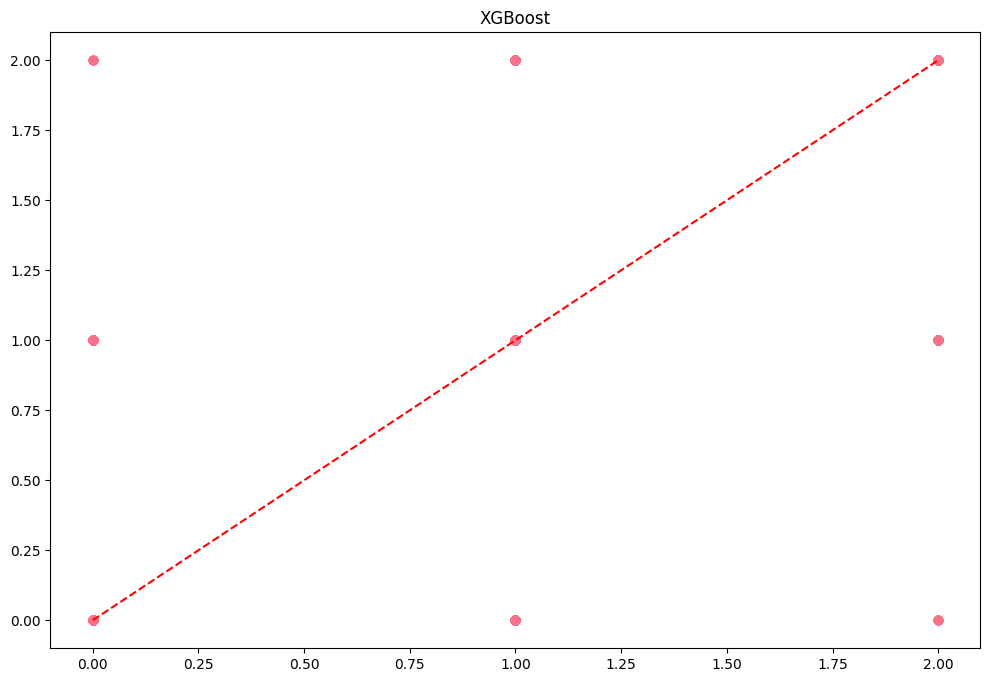

operands could not be broadcast together with shapes (137784,) (34446,) 
Fitting 5 folds for each of 9 candidates, totalling 45 fits

ExtraTrees
Best params: {'max_depth': 20, 'n_estimators': 500}
r2: 0.7350775406274499
rmse: 0.39619481366138143
mae 0.15209313127794227
mse: 0.15697033037217675


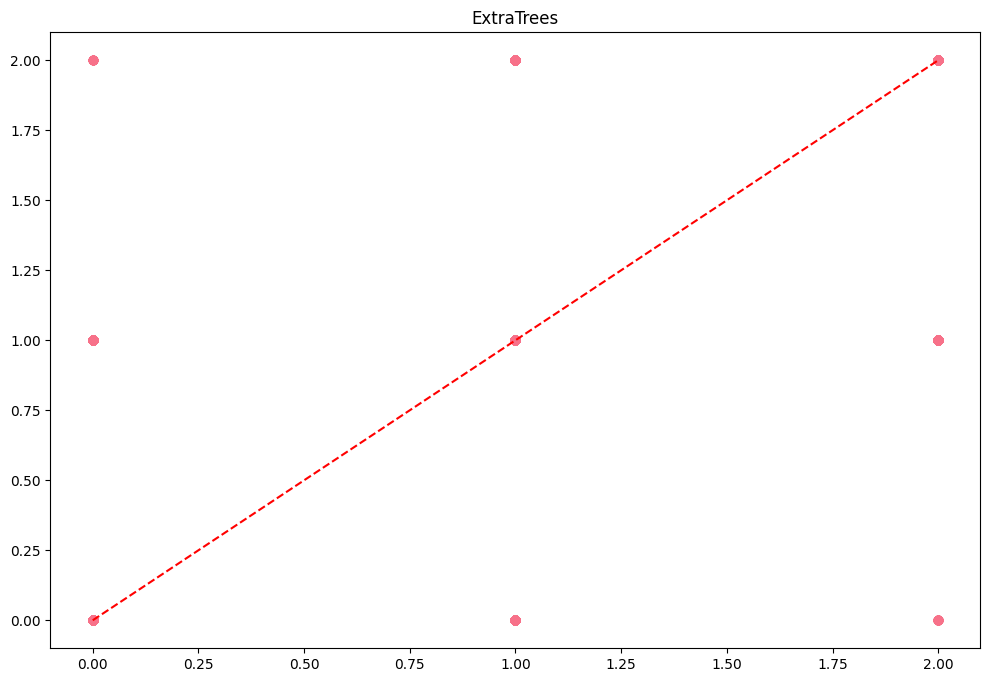

operands could not be broadcast together with shapes (137784,) (34446,) 
Fitting 5 folds for each of 3 candidates, totalling 15 fits

DecisionTree
Best params: {'max_depth': 10}
r2: 0.7142541551579966
rmse: 0.41147112030215477
mae 0.16176043662544273
mse: 0.16930848284271033


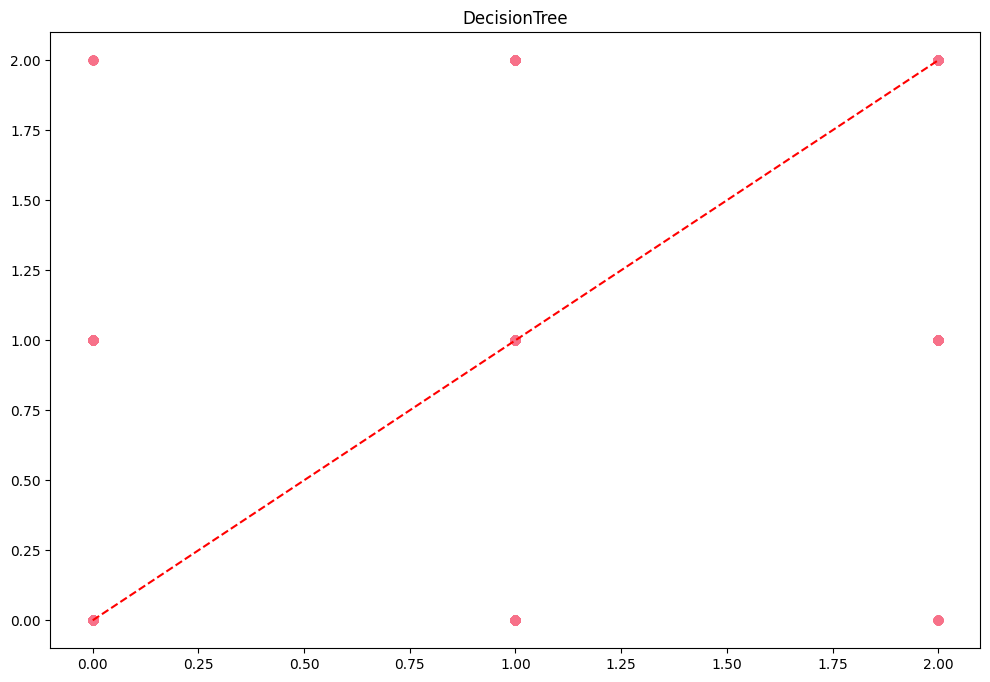

operands could not be broadcast together with shapes (137784,) (34446,) 


In [42]:
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
models = {
    'RandomForest': RandomForestRegressor(),
    'HistoradientBoosting': HistGradientBoostingRegressor(),
    'XGBoost': xgboost.XGBRegressor(),
    'ExtraTrees': ExtraTreesRegressor(),
    'DecisionTree': DecisionTreeRegressor(),
}
param_grids = {
    
    'RandomForest': {
        #'n_estimators': [100, 300, 500],
        'max_depth': [None, 10, 20]
    },
    'XGBoost': {
        'n_estimators': [100, 300, 500],
        'max_depth': [3, 10, 20]
    },
    'ExtraTrees': {
        'n_estimators': [100, 300, 500],
        'max_depth': [None, 10, 20]
    },
    'DecisionTree': {
        'max_depth': [None, 10, 20]
    },
    'HistoradientBoosting':{
        'max_iter':[100,200,300],
        'max_depth':[3,5],
    }
}
results = {}

for name, model in models.items():
    grid = GridSearchCV(model, param_grids[name], cv=5, scoring='neg_mean_squared_error', n_jobs=-1,verbose=1)
    grid.fit(X_train_reduce, y_train_reduce)
    best = grid.best_estimator_
    y_pred = best.predict(X_test_scaled)
    y_pred = np.round(y_pred)
    print(f"\n{name}")
    print(f"Best params: {grid.best_params_}")
    r2 = r2_score(y_test_reduce,y_pred)
    rmse = root_mean_squared_error(y_test_reduce,y_pred)
    mae = mean_absolute_error(y_test_reduce,y_pred)
    mse = mean_squared_error(y_test_reduce,y_pred)
    print(f"r2: {r2}")
    print(f'rmse: {rmse}')
    print(f'mae {mae}')
    print(f'mse: {mse}')
    try:
        plt.scatter(y_test_reduce,y_pred,alpha=0.5)
        plt.plot([y_test_reduce.min(),y_test_reduce.max()],[y_test_reduce.min(),y_test_reduce.max()],'r--')  
        plt.title(f'{name}') 
        plt.show() 
        resudios = y_train_reduce-y_pred
        plt.subplot(1,2,1)
        sns.histplot(resudios,kde=True)
        plt.subplot(1,2,2)
        plt.scatter(y_pred,resudios,alpha=0.5)
        plt.axhline(y=0,color='r',linestyle='--')
        plt.xlabel("prediccines")
        plt.ylabel("residuos")
        plt.tight_layout()
        plt.show()
        from scipy.stats import stats
        stats.probplot(resudios,dist='norm',plot=plt)
        plt.title("QQ-plot")
        plt.show()
    except Exception as e:
        print(e)



In [43]:
"""from sklearn.utils import class_weight
class_wigths = class_weight.compute_class_weight('balanced',classes=np.unique(y),y=y)

w = dict(zip(np.unique(y),class_wigths))
svc = SVC(kernel='rbf',probability=True,cache_size=1000,decision_function_shape='ovr',class_weight=w,verbose=2)
svc.fit(X_train_reduce,y_train_reduce)
y_pred = svc.predict(X_test_scaled)
r = classification_report(y_test_reduce, y_pred)

print(r)
cm = confusion_matrix(y_test_reduce, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['No Popular', 'bajo','media','alta'],
              yticklabels=['No Popular', 'bajo','media','alta'])
plt.ylabel('Valor Real')
plt.xlabel('Predicción')
plt.show()"""

"from sklearn.utils import class_weight\nclass_wigths = class_weight.compute_class_weight('balanced',classes=np.unique(y),y=y)\n\nw = dict(zip(np.unique(y),class_wigths))\nsvc = SVC(kernel='rbf',probability=True,cache_size=1000,decision_function_shape='ovr',class_weight=w,verbose=2)\nsvc.fit(X_train_reduce,y_train_reduce)\ny_pred = svc.predict(X_test_scaled)\nr = classification_report(y_test_reduce, y_pred)\n\nprint(r)\ncm = confusion_matrix(y_test_reduce, y_pred)\nplt.figure(figsize=(8,6))\nsns.heatmap(cm, annot=True, fmt='d', cmap='Blues',\n                xticklabels=['No Popular', 'bajo','media','alta'],\n              yticklabels=['No Popular', 'bajo','media','alta'])\nplt.ylabel('Valor Real')\nplt.xlabel('Predicción')\nplt.show()"

# K=30

Fitting 5 folds for each of 9 candidates, totalling 45 fits
[CV] END ...................max_depth=None, n_estimators=100; total time= 6.4min
[CV] END ...................max_depth=None, n_estimators=100; total time= 6.5min
[CV] END ...................max_depth=None, n_estimators=100; total time= 6.6min
[CV] END ...................max_depth=None, n_estimators=100; total time= 6.7min
[CV] END ...................max_depth=None, n_estimators=100; total time= 6.7min
[CV] END ...................max_depth=None, n_estimators=300; total time=19.2min
[CV] END ...................max_depth=None, n_estimators=300; total time=19.6min
[CV] END ...................max_depth=None, n_estimators=300; total time=19.9min
[CV] END .....................max_depth=10, n_estimators=100; total time= 4.1min
[CV] END ...................max_depth=None, n_estimators=300; total time=19.7min
[CV] END ...................max_depth=None, n_estimators=300; total time=19.9min
[CV] END .....................max_depth=10, n_est

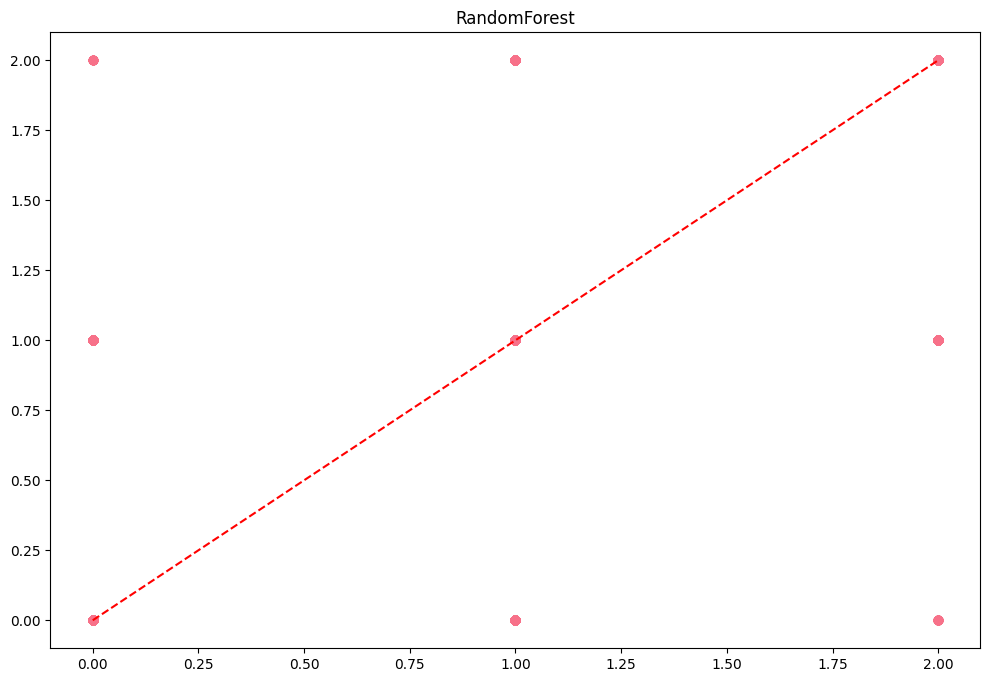

operands could not be broadcast together with shapes (137784,) (34446,) 
Fitting 5 folds for each of 6 candidates, totalling 30 fits
[CV] END ..........................max_depth=3, max_iter=100; total time=   3.3s
[CV] END ..........................max_depth=3, max_iter=100; total time=   3.3s
[CV] END ..........................max_depth=3, max_iter=100; total time=   3.3s
[CV] END ..........................max_depth=3, max_iter=100; total time=   3.3s
[CV] END ..........................max_depth=3, max_iter=100; total time=   3.4s
[CV] END ..........................max_depth=3, max_iter=200; total time=   5.5s
[CV] END ..........................max_depth=3, max_iter=200; total time=   5.5s
[CV] END ..........................max_depth=3, max_iter=200; total time=   5.5s
[CV] END ..........................max_depth=3, max_iter=200; total time=   5.3s
[CV] END ..........................max_depth=3, max_iter=200; total time=   5.3s
[CV] END ..........................max_depth=5, max_iter=

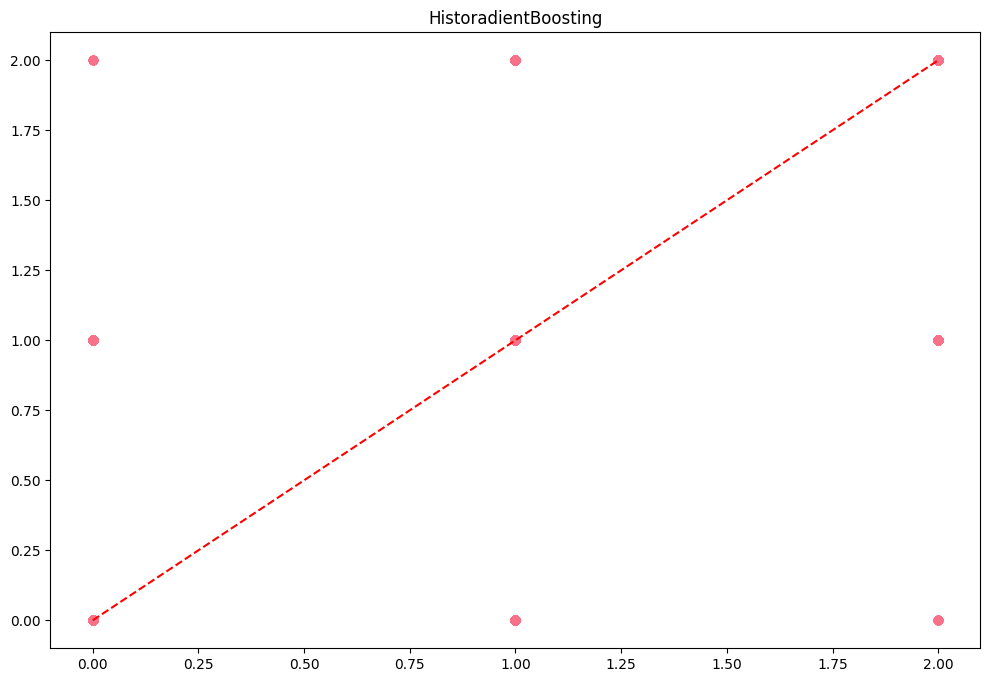

operands could not be broadcast together with shapes (137784,) (34446,) 
Fitting 5 folds for each of 9 candidates, totalling 45 fits
[CV] END ......................max_depth=3, n_estimators=100; total time=   2.6s
[CV] END ......................max_depth=3, n_estimators=100; total time=   2.6s
[CV] END ......................max_depth=3, n_estimators=100; total time=   2.6s
[CV] END ......................max_depth=3, n_estimators=100; total time=   2.6s
[CV] END ......................max_depth=3, n_estimators=100; total time=   2.6s
[CV] END ......................max_depth=3, n_estimators=300; total time=   5.7s
[CV] END ......................max_depth=3, n_estimators=300; total time=   5.7s
[CV] END ......................max_depth=3, n_estimators=300; total time=   5.7s
[CV] END ......................max_depth=3, n_estimators=300; total time=   5.9s
[CV] END ......................max_depth=3, n_estimators=300; total time=   6.0s
[CV] END ......................max_depth=3, n_estimators=

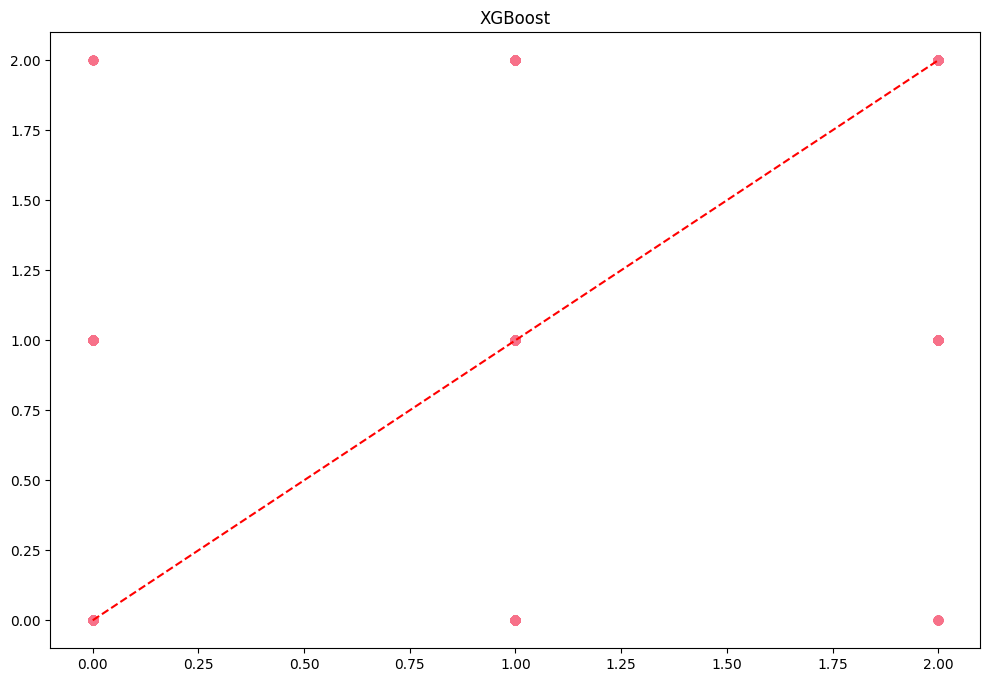

operands could not be broadcast together with shapes (137784,) (34446,) 
Fitting 5 folds for each of 9 candidates, totalling 45 fits
[CV] END ...................max_depth=None, n_estimators=100; total time= 2.5min
[CV] END ...................max_depth=None, n_estimators=100; total time= 2.6min
[CV] END ...................max_depth=None, n_estimators=100; total time= 2.6min
[CV] END ...................max_depth=None, n_estimators=100; total time= 2.6min
[CV] END ...................max_depth=None, n_estimators=100; total time= 2.6min
[CV] END ...................max_depth=None, n_estimators=300; total time= 8.0min
[CV] END ...................max_depth=None, n_estimators=300; total time= 8.1min
[CV] END ...................max_depth=None, n_estimators=300; total time= 8.2min
[CV] END .....................max_depth=10, n_estimators=100; total time= 1.8min
[CV] END ...................max_depth=None, n_estimators=300; total time= 8.4min
[CV] END ...................max_depth=None, n_estimators=

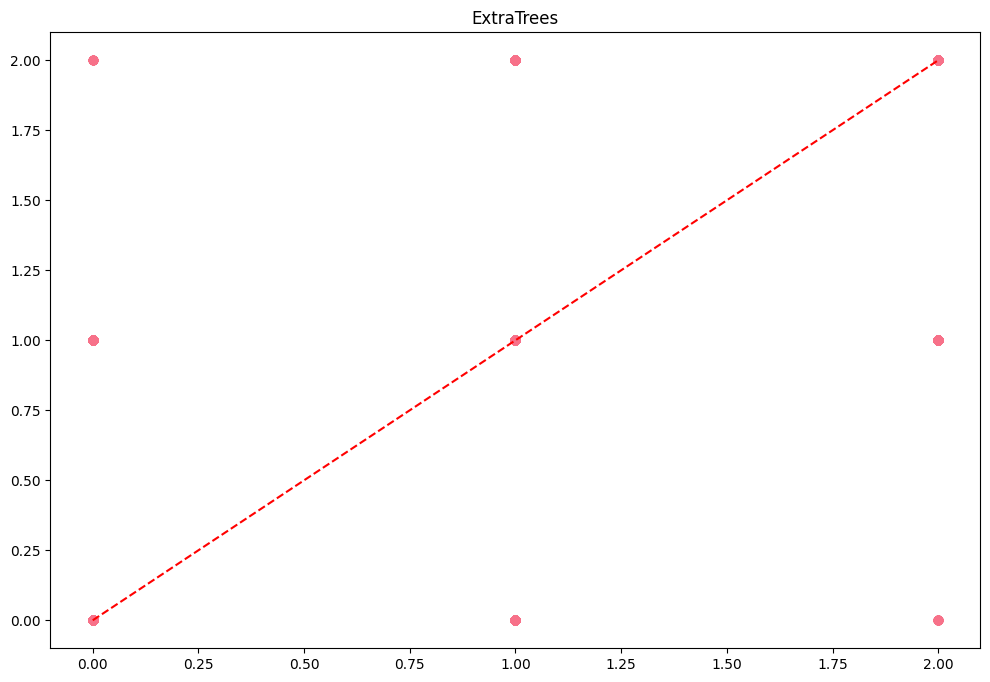

operands could not be broadcast together with shapes (137784,) (34446,) 
Fitting 5 folds for each of 3 candidates, totalling 15 fits
[CV] END .......................................max_depth=10; total time=   3.5s
[CV] END .......................................max_depth=10; total time=   3.6s
[CV] END .......................................max_depth=10; total time=   3.7s
[CV] END .....................................max_depth=None; total time=   5.8s
[CV] END .....................................max_depth=None; total time=   5.8s
[CV] END .....................................max_depth=None; total time=   5.8s
[CV] END .....................................max_depth=None; total time=   5.8s
[CV] END .....................................max_depth=None; total time=   6.0s
[CV] END .......................................max_depth=10; total time=   3.5s
[CV] END .......................................max_depth=10; total time=   3.6s
[CV] END .......................................max_depth

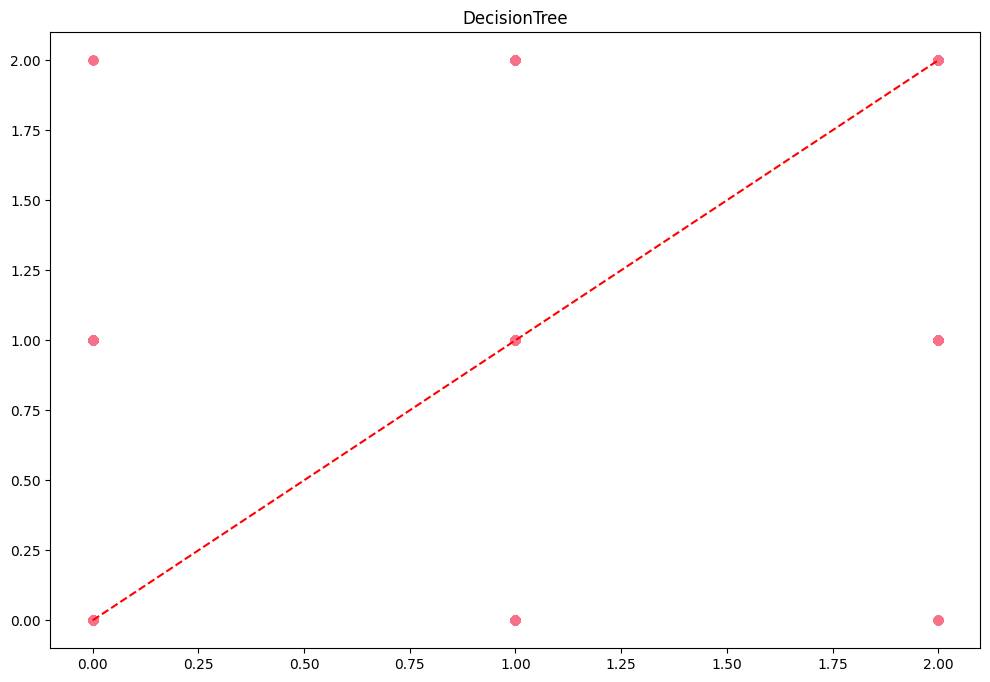

operands could not be broadcast together with shapes (137784,) (34446,) 


In [44]:
selector = SelectKBest(score_func=f_regression,k=30)
X_new = selector.fit_transform(X,y_multiclass_3)
select = selector.get_feature_names_out()
select
_X=X[select]
y =y_multiclass_3
scaler1 = RobustScaler()

X_train_reduce, X_test_reduce, y_train_reduce, y_test_reduce = train_test_split(
    _X, y, 
    test_size=0.2, 
    stratify=y,
    random_state=42
)
X_train_reduce = scaler1.fit_transform(X_train_reduce)
X_test_scaled = scaler1.transform(X_test_reduce)
models = {
    'RandomForest': RandomForestRegressor(),
    'HistoradientBoosting': HistGradientBoostingRegressor(),
    'XGBoost': xgboost.XGBRegressor(),
    'ExtraTrees': ExtraTreesRegressor(),
    'DecisionTree': DecisionTreeRegressor(),
}
param_grids = {
    
    'RandomForest': {
        'n_estimators': [100, 300, 500],
        'max_depth': [None, 10, 20]
    },
    'XGBoost': {
        'n_estimators': [100, 300, 500],
        'max_depth': [3, 10, 20]
    },
    'ExtraTrees': {
        'n_estimators': [100, 300, 500],
        'max_depth': [None, 10, 20]
    },
    'DecisionTree': {
        'max_depth': [None, 10, 20]
    },
    'HistoradientBoosting':{
        'max_iter':[100,200,300],
        'max_depth':[3,5],
    }
}
results = {}

for name, model in models.items():
    grid = GridSearchCV(model, param_grids[name], cv=5, scoring='neg_mean_squared_error', n_jobs=-1,verbose=2)
    grid.fit(X_train_reduce, y_train_reduce)
    best = grid.best_estimator_
    y_pred = best.predict(X_test_scaled)
    y_pred = np.round(y_pred)
    print(f"\n{name}")
    print(f"Best params: {grid.best_params_}")
    r2 = r2_score(y_test_reduce,y_pred)
    rmse = root_mean_squared_error(y_test_reduce,y_pred)
    mae = mean_absolute_error(y_test_reduce,y_pred)
    mse = mean_squared_error(y_test_reduce,y_pred)
    print(f"r2: {r2}")
    print(f'rmse: {rmse}')
    print(f'mae {mae}')
    print(f'mse: {mse}')
    try:
        plt.scatter(y_test_reduce,y_pred,alpha=0.5)
        plt.plot([y_test_reduce.min(),y_test_reduce.max()],[y_test_reduce.min(),y_test_reduce.max()],'r--')  
        plt.title(f'{name}') 
        plt.show() 
        resudios = y_train_reduce-y_pred
        plt.subplot(1,2,1)
        sns.histplot(resudios,kde=True)
        plt.subplot(1,2,2)
        plt.scatter(y_pred,resudios,alpha=0.5)
        plt.axhline(y=0,color='r',linestyle='--')
        plt.xlabel("prediccines")
        plt.ylabel("residuos")
        plt.tight_layout()
        plt.show()
        from scipy.stats import stats
        stats.probplot(resudios,dist='norm',plot=plt)
        plt.title("QQ-plot")
        plt.show()
    except Exception as e:
        print(e)

# k=20


Fitting 5 folds for each of 9 candidates, totalling 45 fits
[CV] END ...................max_depth=None, n_estimators=100; total time= 4.2min
[CV] END ...................max_depth=None, n_estimators=100; total time= 4.3min
[CV] END ...................max_depth=None, n_estimators=100; total time= 4.3min
[CV] END ...................max_depth=None, n_estimators=100; total time= 4.3min
[CV] END ...................max_depth=None, n_estimators=100; total time= 4.4min
[CV] END ...................max_depth=None, n_estimators=300; total time=12.7min
[CV] END ...................max_depth=None, n_estimators=300; total time=12.9min
[CV] END ...................max_depth=None, n_estimators=300; total time=13.1min
[CV] END .....................max_depth=10, n_estimators=100; total time= 2.7min
[CV] END ...................max_depth=None, n_estimators=300; total time=12.9min
[CV] END ...................max_depth=None, n_estimators=300; total time=13.0min
[CV] END .....................max_depth=10, n_est

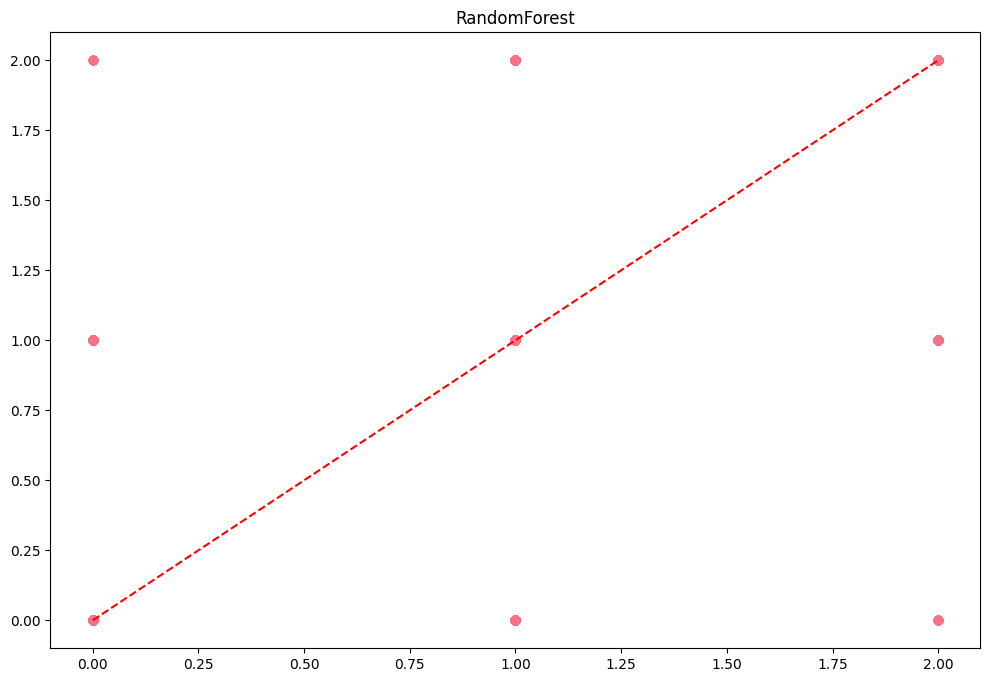

operands could not be broadcast together with shapes (137784,) (34446,) 
Fitting 5 folds for each of 6 candidates, totalling 30 fits
[CV] END ..........................max_depth=3, max_iter=100; total time=   2.4s
[CV] END ..........................max_depth=3, max_iter=100; total time=   2.4s
[CV] END ..........................max_depth=3, max_iter=100; total time=   2.4s
[CV] END ..........................max_depth=3, max_iter=100; total time=   2.4s
[CV] END ..........................max_depth=3, max_iter=100; total time=   2.4s
[CV] END ..........................max_depth=3, max_iter=200; total time=   4.1s
[CV] END ..........................max_depth=3, max_iter=200; total time=   4.1s
[CV] END ..........................max_depth=3, max_iter=200; total time=   4.1s
[CV] END ..........................max_depth=3, max_iter=200; total time=   4.1s
[CV] END ..........................max_depth=3, max_iter=200; total time=   4.2s
[CV] END ..........................max_depth=5, max_iter=

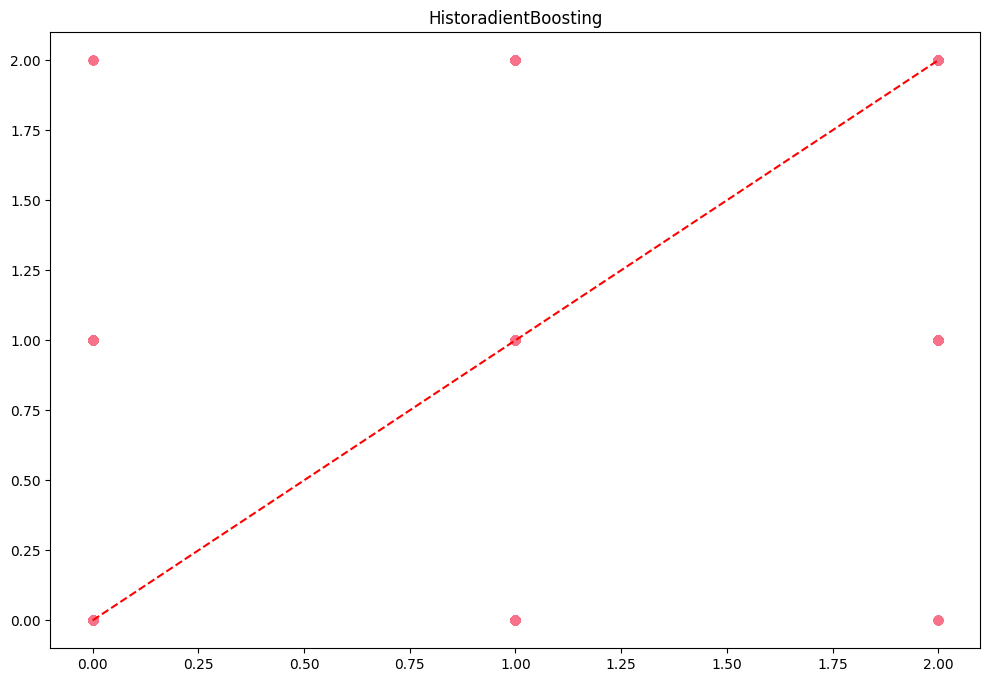

operands could not be broadcast together with shapes (137784,) (34446,) 
Fitting 5 folds for each of 9 candidates, totalling 45 fits
[CV] END ......................max_depth=3, n_estimators=100; total time=   2.0s
[CV] END ......................max_depth=3, n_estimators=100; total time=   2.0s
[CV] END ......................max_depth=3, n_estimators=100; total time=   2.0s
[CV] END ......................max_depth=3, n_estimators=100; total time=   2.0s
[CV] END ......................max_depth=3, n_estimators=100; total time=   2.3s
[CV] END ......................max_depth=3, n_estimators=300; total time=   4.4s
[CV] END ......................max_depth=3, n_estimators=300; total time=   4.4s
[CV] END ......................max_depth=3, n_estimators=300; total time=   4.5s
[CV] END ......................max_depth=3, n_estimators=300; total time=   4.6s
[CV] END ......................max_depth=3, n_estimators=300; total time=   4.6s
[CV] END ......................max_depth=3, n_estimators=

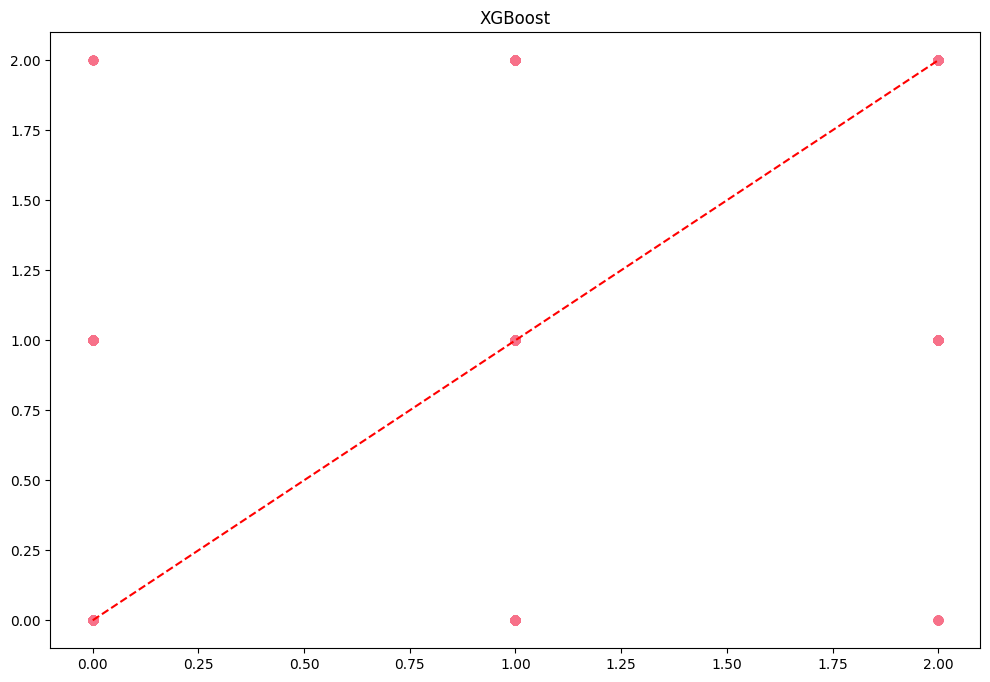

operands could not be broadcast together with shapes (137784,) (34446,) 
Fitting 5 folds for each of 9 candidates, totalling 45 fits
[CV] END ...................max_depth=None, n_estimators=100; total time= 1.7min
[CV] END ...................max_depth=None, n_estimators=100; total time= 1.8min
[CV] END ...................max_depth=None, n_estimators=100; total time= 1.8min
[CV] END ...................max_depth=None, n_estimators=100; total time= 1.8min
[CV] END ...................max_depth=None, n_estimators=100; total time= 1.8min
[CV] END ...................max_depth=None, n_estimators=300; total time= 5.4min
[CV] END ...................max_depth=None, n_estimators=300; total time= 5.5min
[CV] END ...................max_depth=None, n_estimators=300; total time= 5.5min
[CV] END .....................max_depth=10, n_estimators=100; total time= 1.2min
[CV] END ...................max_depth=None, n_estimators=300; total time= 5.7min
[CV] END ...................max_depth=None, n_estimators=

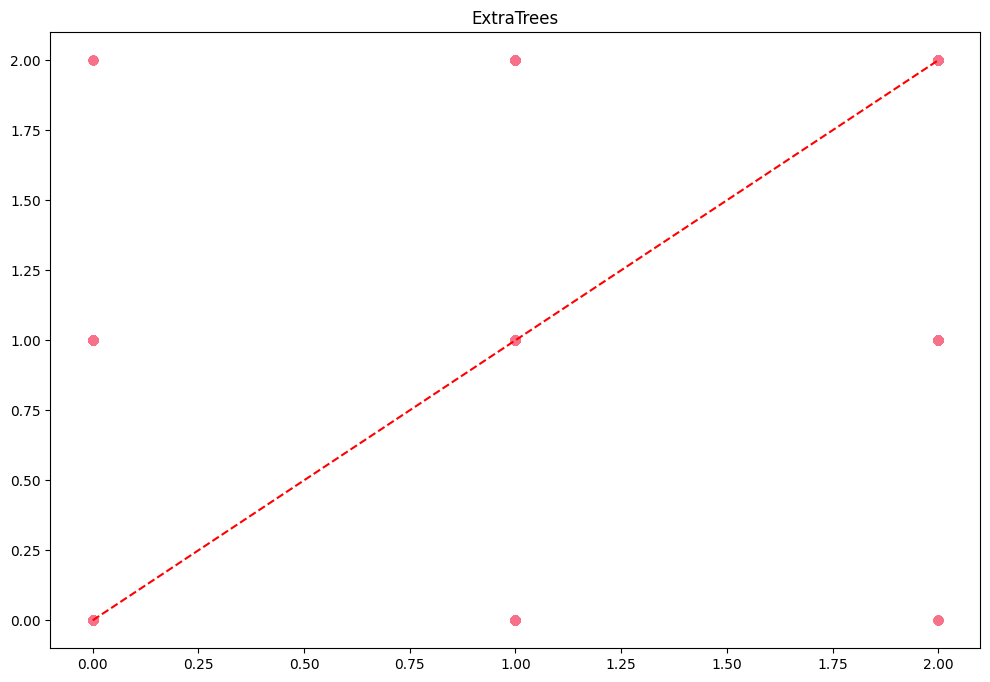

operands could not be broadcast together with shapes (137784,) (34446,) 
Fitting 5 folds for each of 3 candidates, totalling 15 fits
[CV] END .....................................max_depth=None; total time=   3.6s
[CV] END .....................................max_depth=None; total time=   3.6s
[CV] END .....................................max_depth=None; total time=   3.6s
[CV] END .......................................max_depth=10; total time=   2.4s
[CV] END .......................................max_depth=10; total time=   2.4s
[CV] END .......................................max_depth=10; total time=   2.4s
[CV] END .......................................max_depth=10; total time=   2.4s
[CV] END .......................................max_depth=10; total time=   2.4s
[CV] END .......................................max_depth=20; total time=   3.4s
[CV] END .....................................max_depth=None; total time=   3.5s
[CV] END .....................................max_depth=N

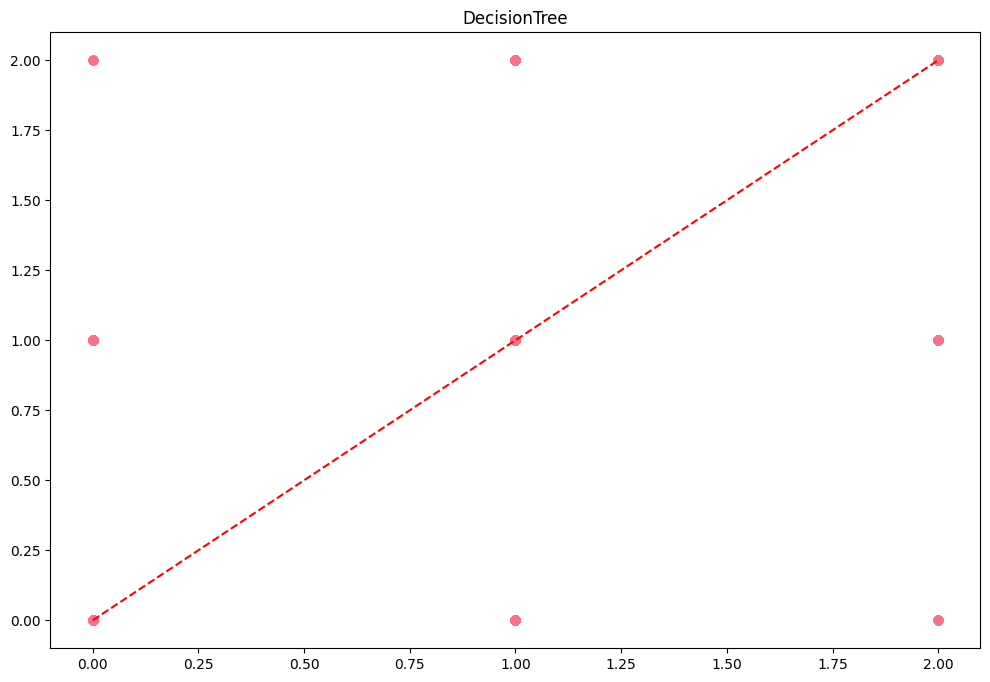

operands could not be broadcast together with shapes (137784,) (34446,) 


In [45]:
selector = SelectKBest(score_func=f_regression,k=20)
X_new = selector.fit_transform(X,y_multiclass_3)
select = selector.get_feature_names_out()
select
_X=X[select]
y =y_multiclass_3
scaler1 = RobustScaler()

X_train_reduce, X_test_reduce, y_train_reduce, y_test_reduce = train_test_split(
    _X, y, 
    test_size=0.2, 
    stratify=y,
    random_state=42
)
X_train_reduce = scaler1.fit_transform(X_train_reduce)
X_test_scaled = scaler1.transform(X_test_reduce)
models = {
    'RandomForest': RandomForestRegressor(),
    'HistoradientBoosting': HistGradientBoostingRegressor(),
    'XGBoost': xgboost.XGBRegressor(),
    'ExtraTrees': ExtraTreesRegressor(),
    'DecisionTree': DecisionTreeRegressor(),
}
param_grids = {
    
    'RandomForest': {
        'n_estimators': [100, 300, 500],
        'max_depth': [None, 10, 20]
    },
    'XGBoost': {
        'n_estimators': [100, 300, 500],
        'max_depth': [3, 10, 20]
    },
    'ExtraTrees': {
        'n_estimators': [100, 300, 500],
        'max_depth': [None, 10, 20]
    },
    'DecisionTree': {
        'max_depth': [None, 10, 20]
    },
    'HistoradientBoosting':{
        'max_iter':[100,200,300],
        'max_depth':[3,5],
    }
}
results = {}

for name, model in models.items():
    grid = GridSearchCV(model, param_grids[name], cv=5, scoring='neg_mean_squared_error', n_jobs=-1,verbose=2)
    grid.fit(X_train_reduce, y_train_reduce)
    best = grid.best_estimator_
    y_pred = best.predict(X_test_scaled)
    y_pred = np.round(y_pred)
    print(f"\n{name}")
    print(f"Best params: {grid.best_params_}")
    r2 = r2_score(y_test_reduce,y_pred)
    rmse = root_mean_squared_error(y_test_reduce,y_pred)
    mae = mean_absolute_error(y_test_reduce,y_pred)
    mse = mean_squared_error(y_test_reduce,y_pred)
    print(f"r2: {r2}")
    print(f'rmse: {rmse}')
    print(f'mae {mae}')
    print(f'mse: {mse}')
    try:
        plt.scatter(y_test_reduce,y_pred,alpha=0.5)
        plt.plot([y_test_reduce.min(),y_test_reduce.max()],[y_test_reduce.min(),y_test_reduce.max()],'r--')  
        plt.title(f'{name}') 
        plt.show() 
        resudios = y_train_reduce-y_pred
        plt.subplot(1,2,1)
        sns.histplot(resudios,kde=True)
        plt.subplot(1,2,2)
        plt.scatter(y_pred,resudios,alpha=0.5)
        plt.axhline(y=0,color='r',linestyle='--')
        plt.xlabel("prediccines")
        plt.ylabel("residuos")
        plt.tight_layout()
        plt.show()
        from scipy.stats import stats
        stats.probplot(resudios,dist='norm',plot=plt)
        plt.title("QQ-plot")
        plt.show()
    except Exception as e:
        print(e)

# k=10


Fitting 5 folds for each of 9 candidates, totalling 45 fits
[CV] END ...................max_depth=None, n_estimators=100; total time= 1.5min
[CV] END ...................max_depth=None, n_estimators=100; total time= 1.6min
[CV] END ...................max_depth=None, n_estimators=100; total time= 1.6min
[CV] END ...................max_depth=None, n_estimators=100; total time= 1.6min
[CV] END ...................max_depth=None, n_estimators=100; total time= 1.6min
[CV] END ...................max_depth=None, n_estimators=300; total time= 4.6min
[CV] END ...................max_depth=None, n_estimators=300; total time= 4.7min
[CV] END ...................max_depth=None, n_estimators=300; total time= 4.7min
[CV] END .....................max_depth=10, n_estimators=100; total time= 1.1min
[CV] END ...................max_depth=None, n_estimators=300; total time= 4.7min
[CV] END ...................max_depth=None, n_estimators=300; total time= 4.7min
[CV] END .....................max_depth=10, n_est

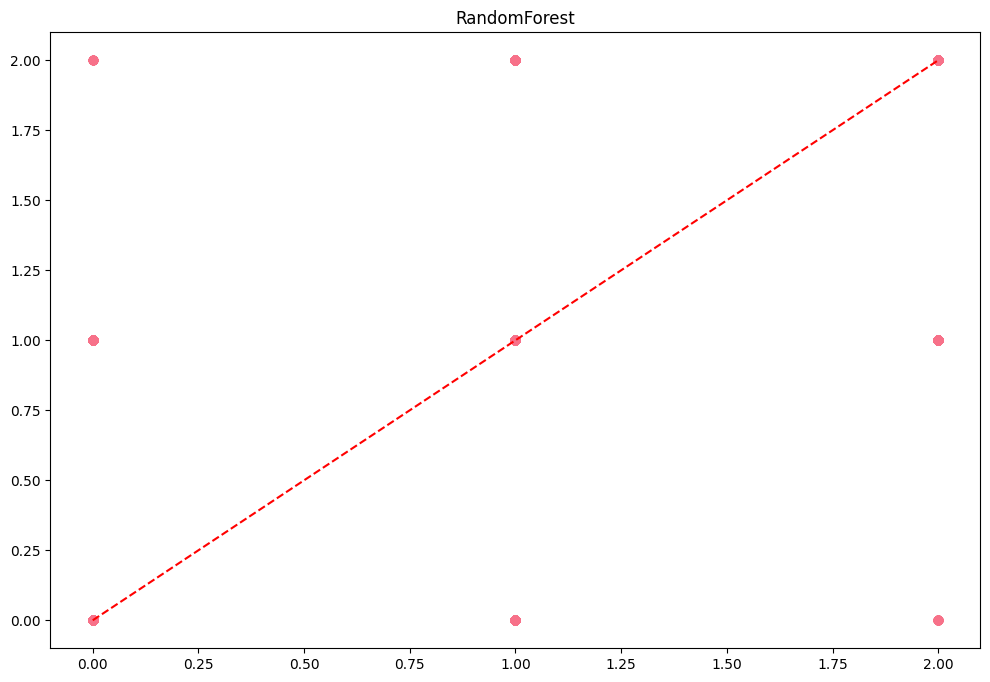

operands could not be broadcast together with shapes (137784,) (34446,) 
Fitting 5 folds for each of 6 candidates, totalling 30 fits
[CV] END ..........................max_depth=3, max_iter=100; total time=   1.5s
[CV] END ..........................max_depth=3, max_iter=100; total time=   1.5s
[CV] END ..........................max_depth=3, max_iter=100; total time=   1.5s
[CV] END ..........................max_depth=3, max_iter=100; total time=   1.5s
[CV] END ..........................max_depth=3, max_iter=100; total time=   1.5s
[CV] END ..........................max_depth=3, max_iter=200; total time=   2.9s
[CV] END ..........................max_depth=3, max_iter=200; total time=   3.0s
[CV] END ..........................max_depth=3, max_iter=300; total time=   4.2s
[CV] END ..........................max_depth=3, max_iter=300; total time=   4.3s
[CV] END ..........................max_depth=3, max_iter=300; total time=   4.3s
[CV] END ..........................max_depth=3, max_iter=

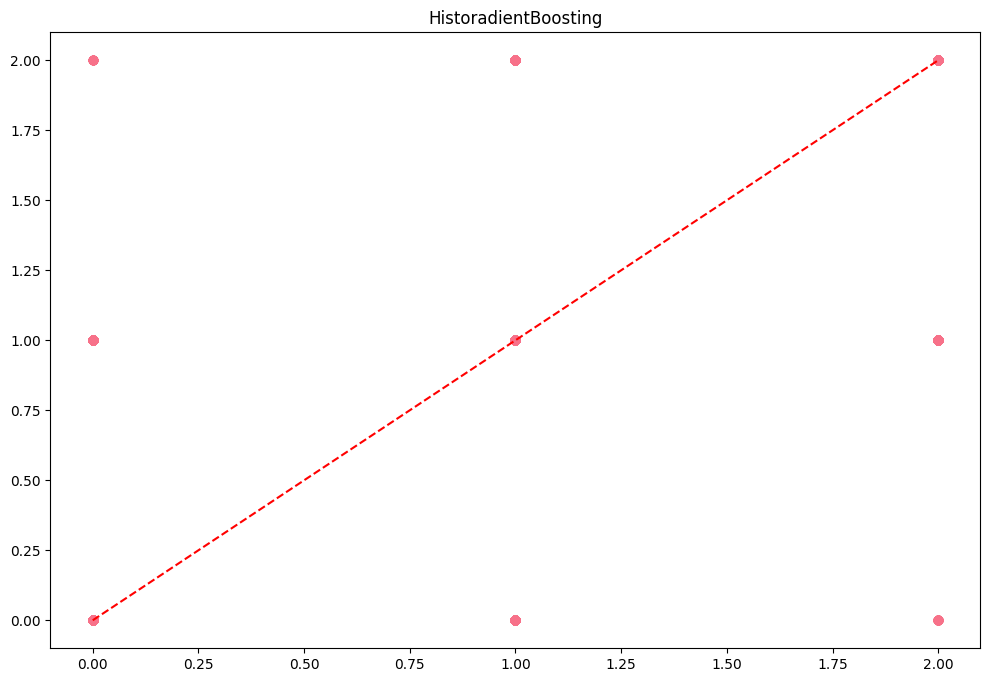

operands could not be broadcast together with shapes (137784,) (34446,) 
Fitting 5 folds for each of 9 candidates, totalling 45 fits
[CV] END ......................max_depth=3, n_estimators=100; total time=   1.4s
[CV] END ......................max_depth=3, n_estimators=100; total time=   1.5s
[CV] END ......................max_depth=3, n_estimators=100; total time=   1.5s
[CV] END ......................max_depth=3, n_estimators=100; total time=   1.5s
[CV] END ......................max_depth=3, n_estimators=100; total time=   1.5s
[CV] END ......................max_depth=3, n_estimators=300; total time=   3.6s
[CV] END ......................max_depth=3, n_estimators=300; total time=   3.6s
[CV] END ......................max_depth=3, n_estimators=300; total time=   3.6s
[CV] END ......................max_depth=3, n_estimators=300; total time=   3.5s
[CV] END ......................max_depth=3, n_estimators=300; total time=   3.7s
[CV] END ......................max_depth=3, n_estimators=

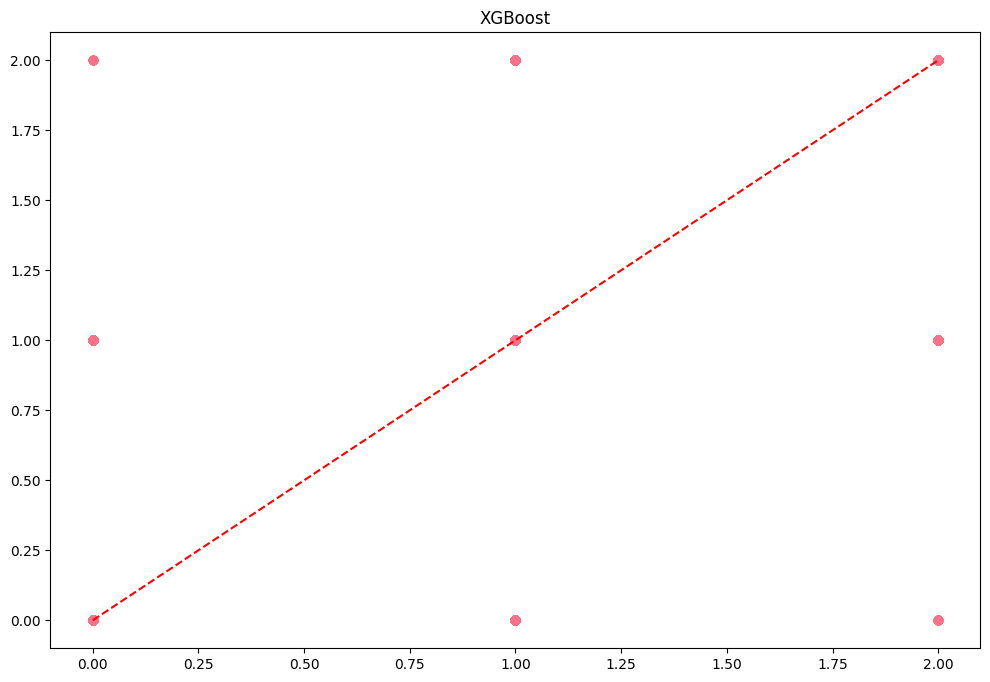

operands could not be broadcast together with shapes (137784,) (34446,) 
Fitting 5 folds for each of 9 candidates, totalling 45 fits
[CV] END ...................max_depth=None, n_estimators=100; total time=  56.6s
[CV] END ...................max_depth=None, n_estimators=100; total time=  56.9s
[CV] END ...................max_depth=None, n_estimators=100; total time=  56.9s
[CV] END ...................max_depth=None, n_estimators=100; total time=  56.9s
[CV] END ...................max_depth=None, n_estimators=100; total time=  57.1s
[CV] END ...................max_depth=None, n_estimators=300; total time= 2.8min
[CV] END ...................max_depth=None, n_estimators=300; total time= 2.8min
[CV] END ...................max_depth=None, n_estimators=300; total time= 2.9min
[CV] END .....................max_depth=10, n_estimators=100; total time=  38.6s
[CV] END ...................max_depth=None, n_estimators=300; total time= 2.9min
[CV] END ...................max_depth=None, n_estimators=

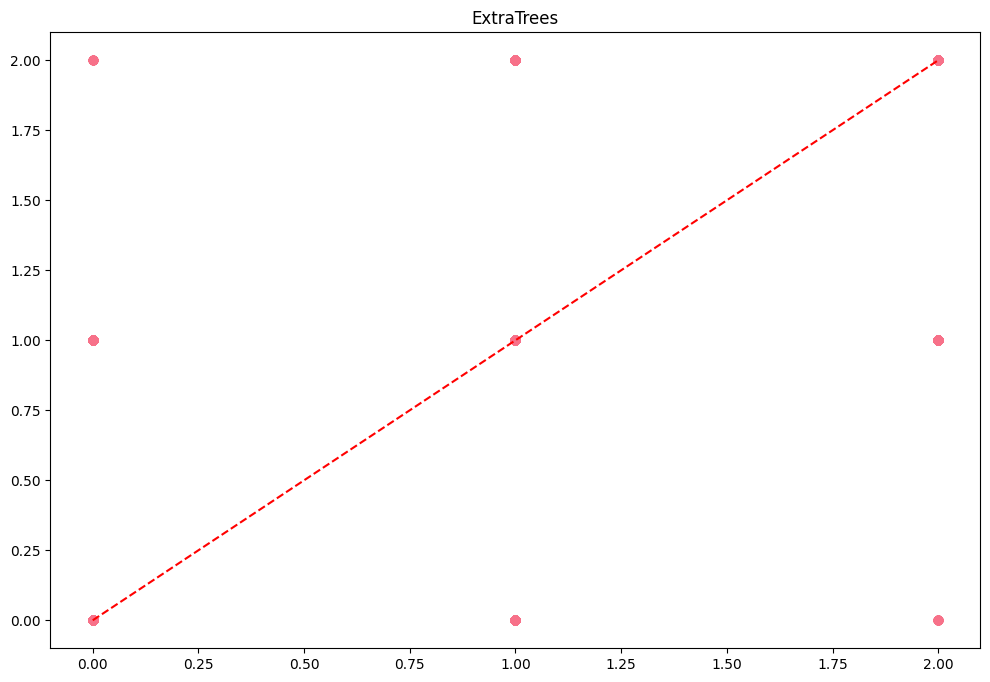

operands could not be broadcast together with shapes (137784,) (34446,) 
Fitting 5 folds for each of 3 candidates, totalling 15 fits
[CV] END .......................................max_depth=10; total time=   1.0s
[CV] END .......................................max_depth=10; total time=   1.0s
[CV] END .......................................max_depth=10; total time=   1.0s
[CV] END .....................................max_depth=None; total time=   1.3s
[CV] END .....................................max_depth=None; total time=   1.3s
[CV] END .....................................max_depth=None; total time=   1.3s
[CV] END .....................................max_depth=None; total time=   1.3s
[CV] END .....................................max_depth=None; total time=   1.4s
[CV] END .......................................max_depth=10; total time=   0.8s
[CV] END .......................................max_depth=10; total time=   0.8s
[CV] END .......................................max_depth

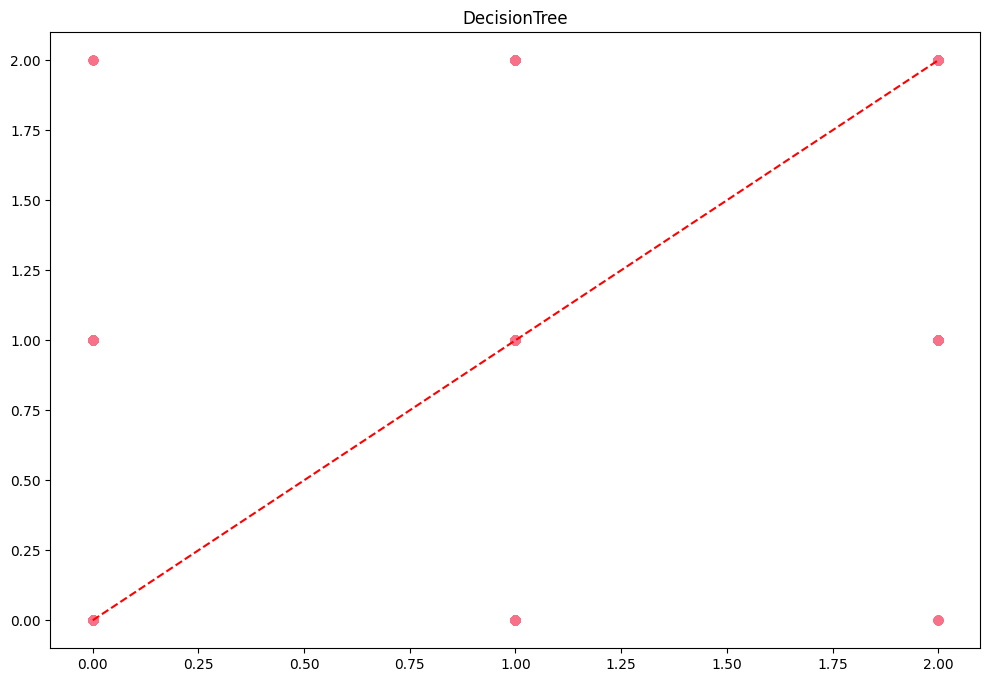

operands could not be broadcast together with shapes (137784,) (34446,) 


In [46]:
selector = SelectKBest(score_func=f_regression,k=10)
X_new = selector.fit_transform(X,y_multiclass_3)
select = selector.get_feature_names_out()
select
_X=X[select]
y =y_multiclass_3
scaler1 = RobustScaler()

X_train_reduce, X_test_reduce, y_train_reduce, y_test_reduce = train_test_split(
    _X, y, 
    test_size=0.2, 
    stratify=y,
    random_state=42
)
X_train_reduce = scaler1.fit_transform(X_train_reduce)
X_test_scaled = scaler1.transform(X_test_reduce)
models = {
    'RandomForest': RandomForestRegressor(),
    'HistoradientBoosting': HistGradientBoostingRegressor(),
    'XGBoost': xgboost.XGBRegressor(),
    'ExtraTrees': ExtraTreesRegressor(),
    'DecisionTree': DecisionTreeRegressor(),
}
param_grids = {
    
    'RandomForest': {
        'n_estimators': [100, 300, 500],
        'max_depth': [None, 10, 20]
    },
    'XGBoost': {
        'n_estimators': [100, 300, 500],
        'max_depth': [3, 10, 20]
    },
    'ExtraTrees': {
        'n_estimators': [100, 300, 500],
        'max_depth': [None, 10, 20]
    },
    'DecisionTree': {
        'max_depth': [None, 10, 20]
    },
    'HistoradientBoosting':{
        'max_iter':[100,200,300],
        'max_depth':[3,5],
    }
}
results = {}

for name, model in models.items():
    grid = GridSearchCV(model, param_grids[name], cv=5, scoring='neg_mean_squared_error', n_jobs=-1,verbose=2)
    grid.fit(X_train_reduce, y_train_reduce)
    best = grid.best_estimator_
    y_pred = best.predict(X_test_scaled)
    y_pred = np.round(y_pred)
    print(f"\n{name}")
    print(f"Best params: {grid.best_params_}")
    r2 = r2_score(y_test_reduce,y_pred)
    rmse = root_mean_squared_error(y_test_reduce,y_pred)
    mae = mean_absolute_error(y_test_reduce,y_pred)
    mse = mean_squared_error(y_test_reduce,y_pred)
    print(f"r2: {r2}")
    print(f'rmse: {rmse}')
    print(f'mae {mae}')
    print(f'mse: {mse}')
    try:
        plt.scatter(y_test_reduce,y_pred,alpha=0.5)
        plt.plot([y_test_reduce.min(),y_test_reduce.max()],[y_test_reduce.min(),y_test_reduce.max()],'r--')  
        plt.title(f'{name}') 
        plt.show() 
        resudios = y_train_reduce-y_pred
        plt.subplot(1,2,1)
        sns.histplot(resudios,kde=True)
        plt.subplot(1,2,2)
        plt.scatter(y_pred,resudios,alpha=0.5)
        plt.axhline(y=0,color='r',linestyle='--')
        plt.xlabel("prediccines")
        plt.ylabel("residuos")
        plt.tight_layout()
        plt.show()
        from scipy.stats import stats
        stats.probplot(resudios,dist='norm',plot=plt)
        plt.title("QQ-plot")
        plt.show()
    except Exception as e:
        print(e)

# PCA n=2

Fitting 5 folds for each of 9 candidates, totalling 45 fits
[CV] END ...................max_depth=None, n_estimators=100; total time= 1.6min
[CV] END ...................max_depth=None, n_estimators=100; total time= 1.6min
[CV] END ...................max_depth=None, n_estimators=100; total time= 1.6min
[CV] END ...................max_depth=None, n_estimators=100; total time= 1.6min
[CV] END ...................max_depth=None, n_estimators=100; total time= 1.6min
[CV] END ...................max_depth=None, n_estimators=300; total time= 4.8min
[CV] END ...................max_depth=None, n_estimators=300; total time= 4.8min
[CV] END ...................max_depth=None, n_estimators=300; total time= 4.8min
[CV] END .....................max_depth=10, n_estimators=100; total time=  47.6s
[CV] END ...................max_depth=None, n_estimators=300; total time= 4.8min
[CV] END ...................max_depth=None, n_estimators=300; total time= 4.8min
[CV] END .....................max_depth=10, n_est

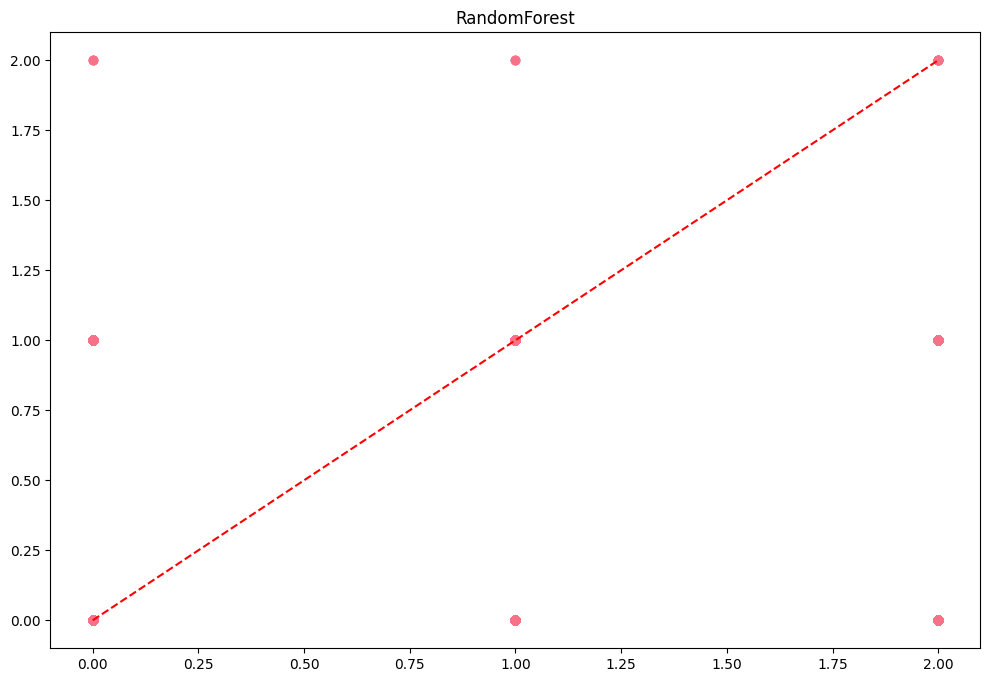

operands could not be broadcast together with shapes (137784,) (34446,) 
Fitting 5 folds for each of 6 candidates, totalling 30 fits
[CV] END ..........................max_depth=3, max_iter=100; total time=   1.1s
[CV] END ..........................max_depth=3, max_iter=100; total time=   1.1s
[CV] END ..........................max_depth=3, max_iter=100; total time=   1.1s
[CV] END ..........................max_depth=3, max_iter=100; total time=   1.1s
[CV] END ..........................max_depth=3, max_iter=100; total time=   1.1s
[CV] END ..........................max_depth=3, max_iter=200; total time=   2.2s
[CV] END ..........................max_depth=3, max_iter=200; total time=   2.2s
[CV] END ..........................max_depth=3, max_iter=300; total time=   2.4s
[CV] END ..........................max_depth=3, max_iter=300; total time=   2.6s
[CV] END ..........................max_depth=3, max_iter=300; total time=   3.1s
[CV] END ..........................max_depth=5, max_iter=

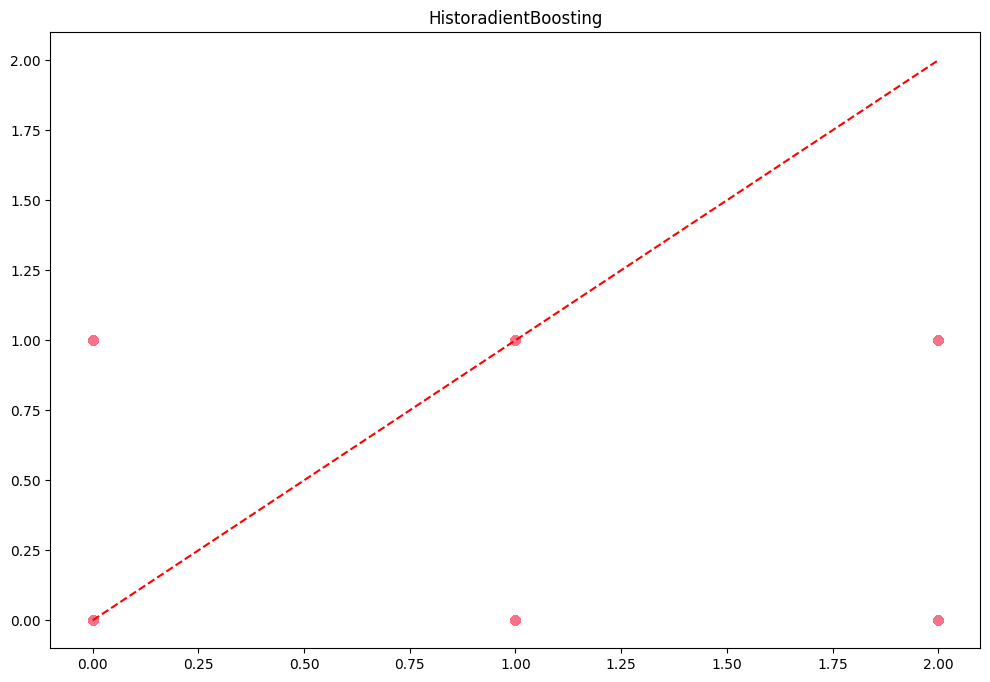

operands could not be broadcast together with shapes (137784,) (34446,) 
Fitting 5 folds for each of 9 candidates, totalling 45 fits
[CV] END ......................max_depth=3, n_estimators=100; total time=   1.1s
[CV] END ......................max_depth=3, n_estimators=100; total time=   1.1s
[CV] END ......................max_depth=3, n_estimators=100; total time=   1.1s
[CV] END ......................max_depth=3, n_estimators=100; total time=   1.2s
[CV] END ......................max_depth=3, n_estimators=100; total time=   1.2s
[CV] END ......................max_depth=3, n_estimators=300; total time=   3.4s
[CV] END ......................max_depth=3, n_estimators=300; total time=   3.4s
[CV] END ......................max_depth=3, n_estimators=300; total time=   3.5s
[CV] END ......................max_depth=3, n_estimators=300; total time=   3.3s
[CV] END ......................max_depth=3, n_estimators=300; total time=   3.4s
[CV] END ......................max_depth=3, n_estimators=

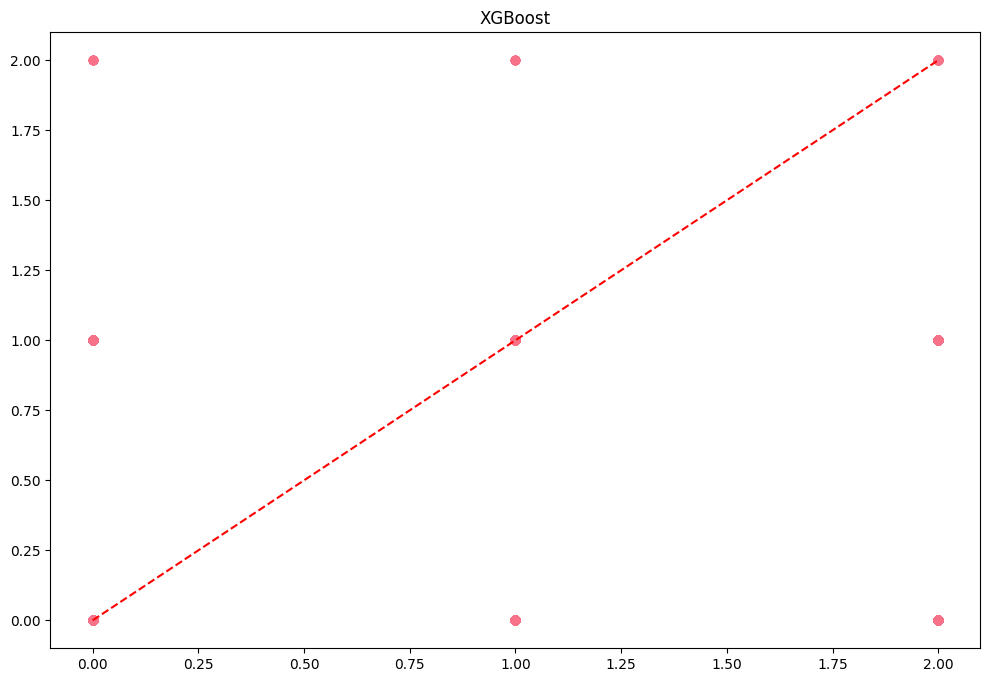

operands could not be broadcast together with shapes (137784,) (34446,) 
Fitting 5 folds for each of 9 candidates, totalling 45 fits
[CV] END ...................max_depth=None, n_estimators=100; total time=  34.8s
[CV] END ...................max_depth=None, n_estimators=100; total time=  34.8s
[CV] END ...................max_depth=None, n_estimators=100; total time=  35.0s
[CV] END ...................max_depth=None, n_estimators=100; total time=  35.1s
[CV] END ...................max_depth=None, n_estimators=100; total time=  35.2s
[CV] END ...................max_depth=None, n_estimators=300; total time= 2.1min
[CV] END ...................max_depth=None, n_estimators=300; total time= 2.1min
[CV] END ...................max_depth=None, n_estimators=300; total time= 2.1min
[CV] END .....................max_depth=10, n_estimators=100; total time=   6.0s
[CV] END .....................max_depth=10, n_estimators=100; total time=   5.3s
[CV] END .....................max_depth=10, n_estimators=

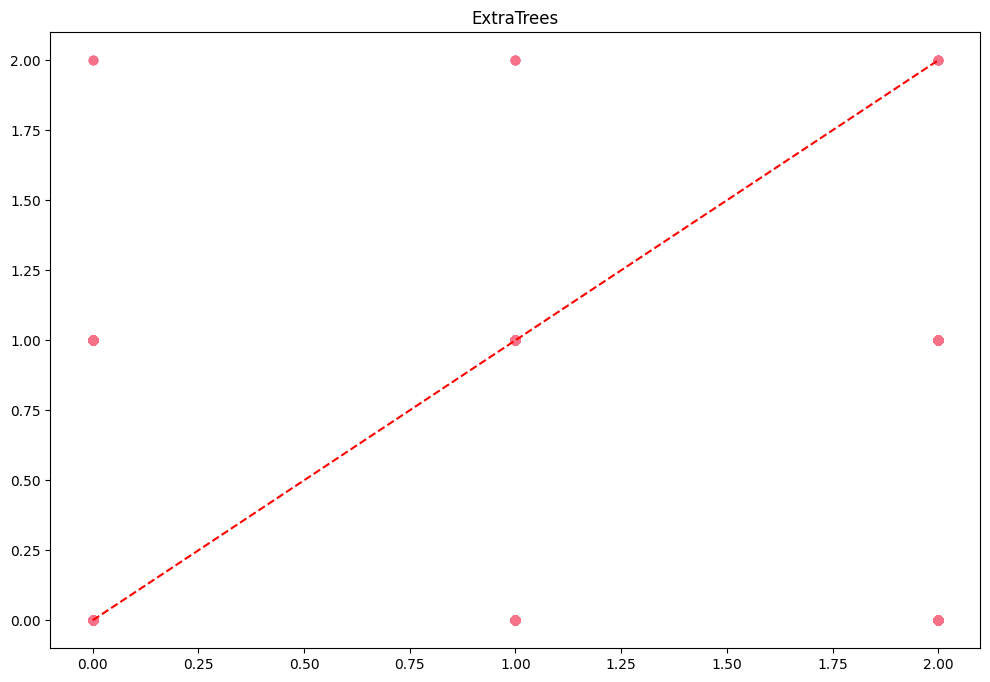

operands could not be broadcast together with shapes (137784,) (34446,) 
Fitting 5 folds for each of 3 candidates, totalling 15 fits
[CV] END .......................................max_depth=10; total time=   0.7s
[CV] END .......................................max_depth=10; total time=   0.8s
[CV] END .......................................max_depth=10; total time=   0.8s
[CV] END .......................................max_depth=10; total time=   0.7s
[CV] END .......................................max_depth=10; total time=   0.7s
[CV] END .....................................max_depth=None; total time=   1.6s
[CV] END .....................................max_depth=None; total time=   1.7s
[CV] END .....................................max_depth=None; total time=   1.7s
[CV] END .....................................max_depth=None; total time=   1.6s
[CV] END .....................................max_depth=None; total time=   1.6s
[CV] END .......................................max_depth

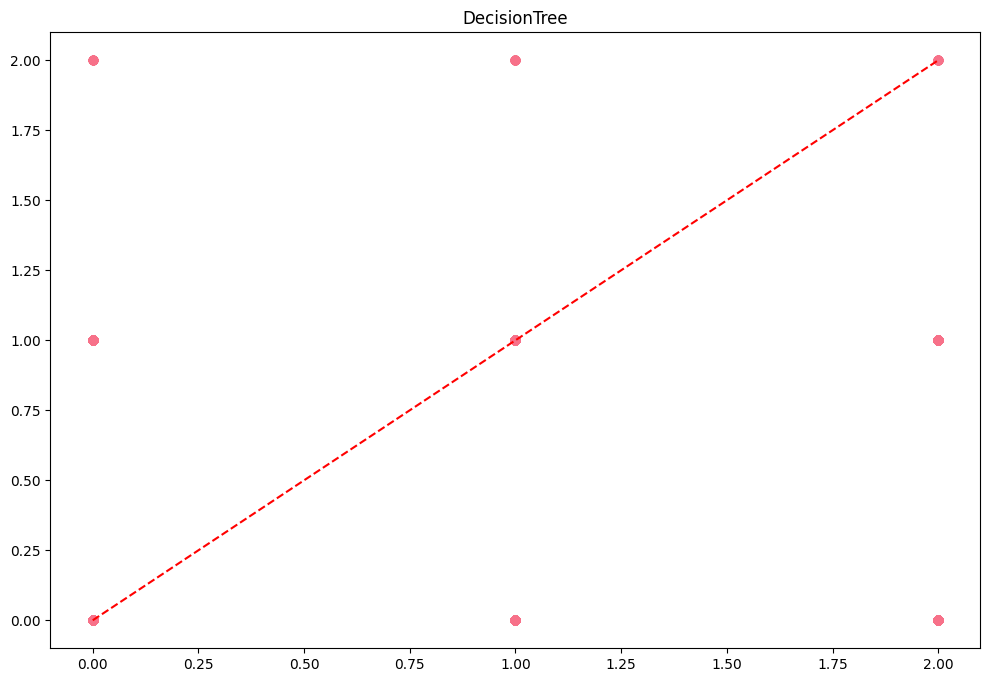

operands could not be broadcast together with shapes (137784,) (34446,) 


In [47]:
from sklearn.decomposition import PCA
_X=X.copy()
y =y_multiclass_3
scaler1 = RobustScaler()

X_train_reduce, X_test_reduce, y_train_reduce, y_test_reduce = train_test_split(
    _X, y, 
    test_size=0.2, 
    stratify=y,
    random_state=42
)
pca = PCA(n_components=2)
X_train_reduce = scaler1.fit_transform(X_train_reduce)
X_test_scaled = scaler1.transform(X_test_reduce)

X_train_reduce = pca.fit_transform(X_train_reduce)
X_test_scaled = pca.transform(X_test_scaled)

models = {
    'RandomForest': RandomForestRegressor(),
    'HistoradientBoosting': HistGradientBoostingRegressor(),
    'XGBoost': xgboost.XGBRegressor(),
    'ExtraTrees': ExtraTreesRegressor(),
    'DecisionTree': DecisionTreeRegressor(),
}
param_grids = {
    
    'RandomForest': {
        'n_estimators': [100, 300, 500],
        'max_depth': [None, 10, 20]
    },
    'XGBoost': {
        'n_estimators': [100, 300, 500],
        'max_depth': [3, 10, 20]
    },
    'ExtraTrees': {
        'n_estimators': [100, 300, 500],
        'max_depth': [None, 10, 20]
    },
    'DecisionTree': {
        'max_depth': [None, 10, 20]
    },
    'HistoradientBoosting':{
        'max_iter':[100,200,300],
        'max_depth':[3,5],
    }
}
results = {}

for name, model in models.items():
    grid = GridSearchCV(model, param_grids[name], cv=5, scoring='neg_mean_squared_error', n_jobs=-1,verbose=2)
    grid.fit(X_train_reduce, y_train_reduce)
    best = grid.best_estimator_
    y_pred = best.predict(X_test_scaled)
    y_pred = np.round(y_pred)
    print(f"\n{name}")
    print(f"Best params: {grid.best_params_}")
    r2 = r2_score(y_test_reduce,y_pred)
    rmse = root_mean_squared_error(y_test_reduce,y_pred)
    mae = mean_absolute_error(y_test_reduce,y_pred)
    mse = mean_squared_error(y_test_reduce,y_pred)
    print(f"r2: {r2}")
    print(f'rmse: {rmse}')
    print(f'mae {mae}')
    print(f'mse: {mse}')
    try:
        plt.scatter(y_test_reduce,y_pred,alpha=0.5)
        plt.plot([y_test_reduce.min(),y_test_reduce.max()],[y_test_reduce.min(),y_test_reduce.max()],'r--')  
        plt.title(f'{name}') 
        plt.show() 
        resudios = y_train_reduce-y_pred
        plt.subplot(1,2,1)
        sns.histplot(resudios,kde=True)
        plt.subplot(1,2,2)
        plt.scatter(y_pred,resudios,alpha=0.5)
        plt.axhline(y=0,color='r',linestyle='--')
        plt.xlabel("prediccines")
        plt.ylabel("residuos")
        plt.tight_layout()
        plt.show()
        from scipy.stats import stats
        stats.probplot(resudios,dist='norm',plot=plt)
        plt.title("QQ-plot")
        plt.show()
    except Exception as e:
        print(e)

# PCA n=85%

Fitting 5 folds for each of 9 candidates, totalling 45 fits
[CV] END ...................max_depth=None, n_estimators=100; total time= 1.4min
[CV] END ...................max_depth=None, n_estimators=100; total time= 1.4min
[CV] END ...................max_depth=None, n_estimators=100; total time= 1.4min
[CV] END ...................max_depth=None, n_estimators=100; total time= 1.4min
[CV] END ...................max_depth=None, n_estimators=100; total time= 1.4min
[CV] END ...................max_depth=None, n_estimators=300; total time= 4.3min
[CV] END ...................max_depth=None, n_estimators=300; total time= 4.3min
[CV] END ...................max_depth=None, n_estimators=300; total time= 4.4min
[CV] END .....................max_depth=10, n_estimators=100; total time=  31.4s
[CV] END .....................max_depth=10, n_estimators=100; total time=  31.4s
[CV] END ...................max_depth=None, n_estimators=300; total time= 4.2min
[CV] END ...................max_depth=None, n_est

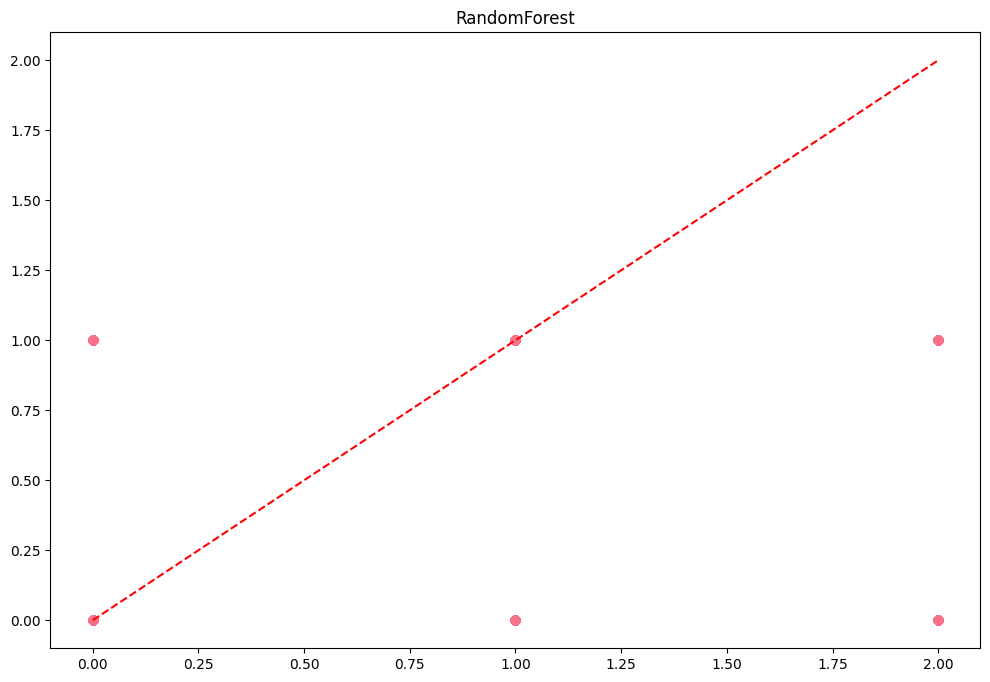

operands could not be broadcast together with shapes (137784,) (34446,) 
Fitting 5 folds for each of 6 candidates, totalling 30 fits
[CV] END ..........................max_depth=3, max_iter=100; total time=   0.8s
[CV] END ..........................max_depth=3, max_iter=200; total time=   0.9s
[CV] END ..........................max_depth=3, max_iter=200; total time=   0.9s
[CV] END ..........................max_depth=3, max_iter=100; total time=   1.0s
[CV] END ..........................max_depth=3, max_iter=100; total time=   1.0s
[CV] END ..........................max_depth=3, max_iter=200; total time=   1.0s
[CV] END ..........................max_depth=3, max_iter=100; total time=   1.1s
[CV] END ..........................max_depth=3, max_iter=100; total time=   1.1s
[CV] END ..........................max_depth=3, max_iter=300; total time=   0.7s
[CV] END ..........................max_depth=3, max_iter=300; total time=   0.7s
[CV] END ..........................max_depth=3, max_iter=

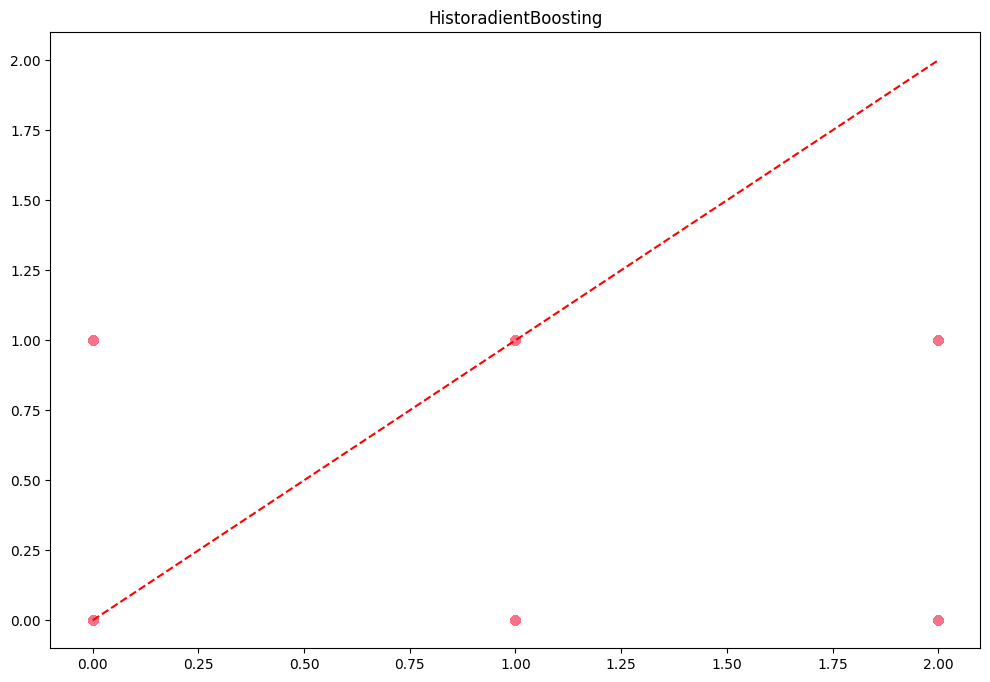

operands could not be broadcast together with shapes (137784,) (34446,) 
Fitting 5 folds for each of 9 candidates, totalling 45 fits
[CV] END ......................max_depth=3, n_estimators=100; total time=   1.0s
[CV] END ......................max_depth=3, n_estimators=100; total time=   1.1s
[CV] END ......................max_depth=3, n_estimators=100; total time=   1.1s
[CV] END ......................max_depth=3, n_estimators=100; total time=   1.1s
[CV] END ......................max_depth=3, n_estimators=100; total time=   1.1s
[CV] END ......................max_depth=3, n_estimators=300; total time=   3.2s
[CV] END ......................max_depth=3, n_estimators=300; total time=   3.2s
[CV] END ......................max_depth=3, n_estimators=300; total time=   3.2s
[CV] END ......................max_depth=3, n_estimators=300; total time=   3.2s
[CV] END ......................max_depth=3, n_estimators=300; total time=   3.2s
[CV] END .....................max_depth=10, n_estimators=

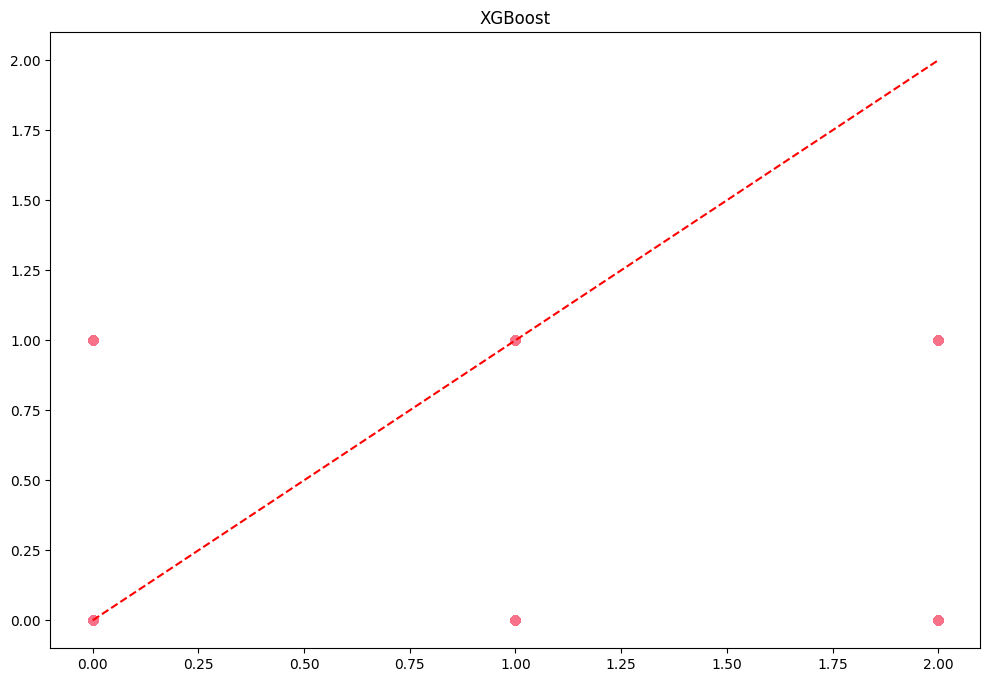

operands could not be broadcast together with shapes (137784,) (34446,) 
Fitting 5 folds for each of 9 candidates, totalling 45 fits
[CV] END ...................max_depth=None, n_estimators=100; total time=  27.7s
[CV] END ...................max_depth=None, n_estimators=100; total time=  27.7s
[CV] END ...................max_depth=None, n_estimators=100; total time=  27.8s
[CV] END ...................max_depth=None, n_estimators=100; total time=  27.8s
[CV] END ...................max_depth=None, n_estimators=100; total time=  27.9s
[CV] END ...................max_depth=None, n_estimators=300; total time= 1.8min
[CV] END ...................max_depth=None, n_estimators=300; total time= 1.8min
[CV] END ...................max_depth=None, n_estimators=300; total time= 1.8min
[CV] END .....................max_depth=10, n_estimators=100; total time=   4.7s
[CV] END .....................max_depth=10, n_estimators=100; total time=   3.2s
[CV] END .....................max_depth=10, n_estimators=

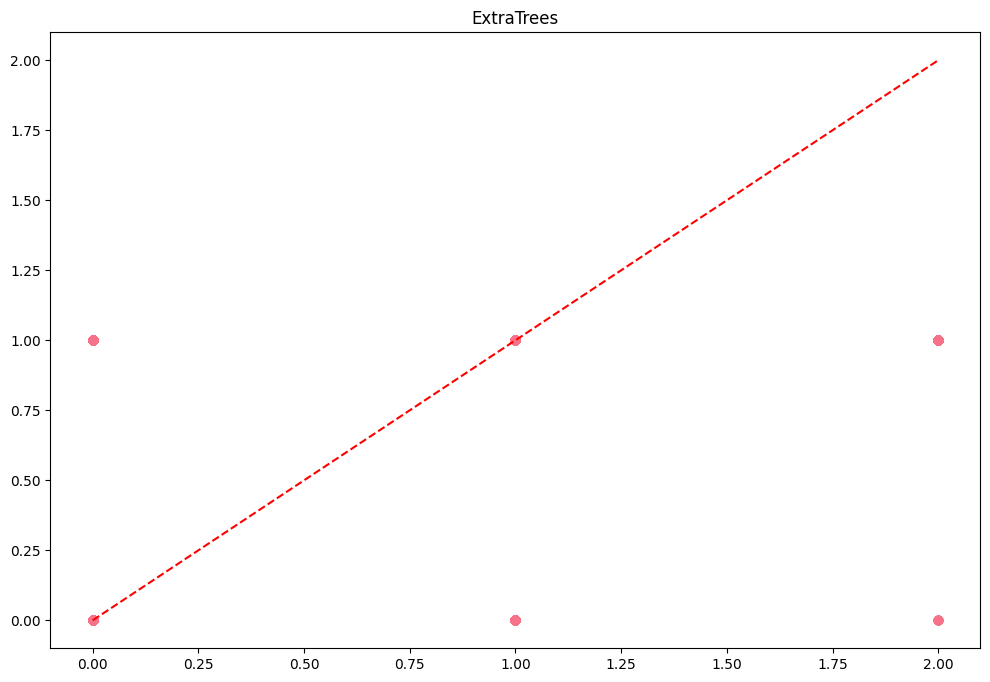

operands could not be broadcast together with shapes (137784,) (34446,) 
Fitting 5 folds for each of 3 candidates, totalling 15 fits
[CV] END .......................................max_depth=10; total time=   0.5s
[CV] END .......................................max_depth=10; total time=   0.5s
[CV] END .......................................max_depth=10; total time=   0.5s
[CV] END .......................................max_depth=10; total time=   0.5s
[CV] END .......................................max_depth=10; total time=   0.5s
[CV] END .....................................max_depth=None; total time=   1.3s
[CV] END .....................................max_depth=None; total time=   1.3s
[CV] END .....................................max_depth=None; total time=   1.4s
[CV] END .......................................max_depth=20; total time=   0.8s
[CV] END .....................................max_depth=None; total time=   1.5s
[CV] END .....................................max_depth=N

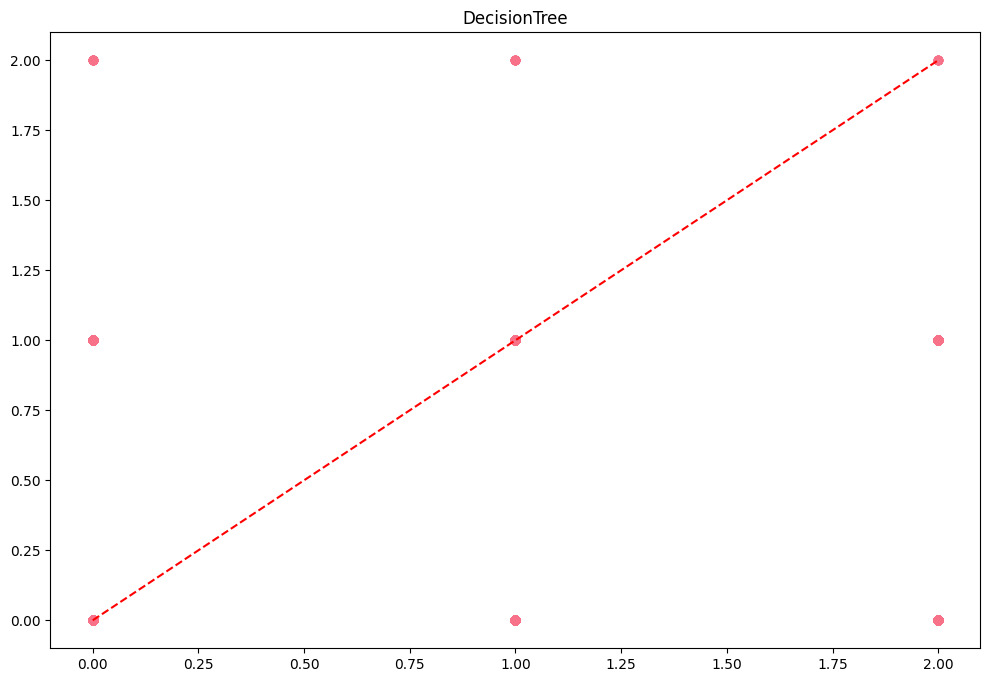

operands could not be broadcast together with shapes (137784,) (34446,) 


In [48]:
from sklearn.decomposition import PCA
_X=X.copy()
y =y_multiclass_3
scaler1 = RobustScaler()

X_train_reduce, X_test_reduce, y_train_reduce, y_test_reduce = train_test_split(
    _X, y, 
    test_size=0.2, 
    stratify=y,
    random_state=42
)
pca = PCA(n_components=0.85)
X_train_reduce = scaler1.fit_transform(X_train_reduce)
X_test_scaled = scaler1.transform(X_test_reduce)

X_train_reduce = pca.fit_transform(X_train_reduce)
X_test_scaled = pca.transform(X_test_scaled)

models = {
    'RandomForest': RandomForestRegressor(),
    'HistoradientBoosting': HistGradientBoostingRegressor(),
    'XGBoost': xgboost.XGBRegressor(),
    'ExtraTrees': ExtraTreesRegressor(),
    'DecisionTree': DecisionTreeRegressor(),
}
param_grids = {
    
    'RandomForest': {
        'n_estimators': [100, 300, 500],
        'max_depth': [None, 10, 20]
    },
    'XGBoost': {
        'n_estimators': [100, 300, 500],
        'max_depth': [3, 10, 20]
    },
    'ExtraTrees': {
        'n_estimators': [100, 300, 500],
        'max_depth': [None, 10, 20]
    },
    'DecisionTree': {
        'max_depth': [None, 10, 20]
    },
    'HistoradientBoosting':{
        'max_iter':[100,200,300],
        'max_depth':[3,5],
    }
}
results = {}

for name, model in models.items():
    grid = GridSearchCV(model, param_grids[name], cv=5, scoring='neg_mean_squared_error', n_jobs=-1,verbose=2)
    grid.fit(X_train_reduce, y_train_reduce)
    best = grid.best_estimator_
    y_pred = best.predict(X_test_scaled)
    y_pred = np.round(y_pred)
    print(f"\n{name}")
    print(f"Best params: {grid.best_params_}")
    r2 = r2_score(y_test_reduce,y_pred)
    rmse = root_mean_squared_error(y_test_reduce,y_pred)
    mae = mean_absolute_error(y_test_reduce,y_pred)
    mse = mean_squared_error(y_test_reduce,y_pred)
    print(f"r2: {r2}")
    print(f'rmse: {rmse}')
    print(f'mae {mae}')
    print(f'mse: {mse}')
    try:
        plt.scatter(y_test_reduce,y_pred,alpha=0.5)
        plt.plot([y_test_reduce.min(),y_test_reduce.max()],[y_test_reduce.min(),y_test_reduce.max()],'r--')  
        plt.title(f'{name}') 
        plt.show() 
        resudios = y_train_reduce-y_pred
        plt.subplot(1,2,1)
        sns.histplot(resudios,kde=True)
        plt.subplot(1,2,2)
        plt.scatter(y_pred,resudios,alpha=0.5)
        plt.axhline(y=0,color='r',linestyle='--')
        plt.xlabel("prediccines")
        plt.ylabel("residuos")
        plt.tight_layout()
        plt.show()
        from scipy.stats import stats
        stats.probplot(resudios,dist='norm',plot=plt)
        plt.title("QQ-plot")
        plt.show()
    except Exception as e:
        print(e)